Entrenamiento del Modelo MassBalanceMachine XGBoost — Chile (con regionalización)

<p style="text-align: justify;">
Este notebook presenta la simulación del balance de masa superficial glaciar para <strong>Chile</strong> usando un modelo personalizado de
<a href="https://xgboost.readthedocs.io/en/stable/">XGBoost</a>. El modelo se configura con una función objetivo específica para producir
predicciones mensuales a partir de datos observacionales agregados. Se instancia un <code>CustomXGBoostRegressor</code> y se entrena con los
datos de estacas preparados previamente. El flujo está <strong>basado en una regionalización explícita</strong> (p. ej., “Desert Andes”,
“Central Andes”, “North Patagonian Andes”, “South Patagonian Andes”) que guía el filtrado, el entrenamiento y la evaluación.
</p>

<p style="text-align: justify;">El flujo de trabajo incluye los siguientes pasos clave:</p>

<ol style="margin-left: 20px; padding-left: 0;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Carga y preparación de datos por región:</strong> Se crea un <code>DataLoader</code> para gestionar la ingesta de datos,
      construir las particiones de entrenamiento y prueba y generar los pliegues de validación cruzada respetando la selección regional.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Validación cruzada y entrenamiento:</strong> Con las particiones definidas, se exploran hiperparámetros (Grid/Randomized Search)
      y se entrena el modelo, obteniendo una evaluación robusta y comparable entre regiones.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Predicciones agregadas:</strong> Tras el entrenamiento, se generan predicciones mensuales y se agregan por ID y por región para
      facilitar el análisis comparativo interregional.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Evaluación del modelo:</strong> Se reportan métricas en el conjunto de prueba a nivel país y desglosadas por región, lo que
      permite cuantificar la precisión y detectar diferencias entre unidades regionales.
    </p>
  </li>
</ol>

<hr />

<p style="text-align: justify;">
This notebook presents glacier surface mass-balance simulation for <strong>Chile</strong> using a custom
<a href="https://xgboost.readthedocs.io/en/stable/">XGBoost</a> model. The model is configured with a task-specific objective to produce
monthly predictions from aggregated observational data. A <code>CustomXGBoostRegressor</code> is instantiated and trained on the previously
prepared stake measurements. The workflow is <strong>grounded in explicit regionalization</strong> (e.g., “Desert Andes”, “Central Andes”,
“North Patagonian Andes”, “South Patagonian Andes”), which drives filtering, training, and evaluation.
</p>

<p style="text-align: justify;">The workflow includes the following key steps:</p>

<ol style="margin-left: 20px; padding-left: 0;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Region-based data loading and preparation:</strong> A <code>DataLoader</code> is used to handle data ingestion, build
      train/test splits, and create cross-validation folds while respecting the selected regions.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Cross-validation and training:</strong> With the folds defined, hyperparameters are explored (Grid/Randomized Search) and the
      model is trained, yielding robust and region-comparable evaluation.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Aggregated predictions:</strong> After training, monthly predictions are produced and aggregated by ID and by region to support
      inter-regional comparison.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Model evaluation:</strong> Test-set metrics are reported at country level and broken down by region, enabling accuracy
      assessment and the identification of regional differences.
    </p>
  </li>
</ol>


In [1]:
import pandas as pd
import massbalancemachine as mbm
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as tnn
from skorch.helper import SliceDataset

In [21]:
# Load monthly dataset and inspect size
# Cargar el dataset mensual y revisar su tamaño
data_df = pd.read_csv('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/files/CL_monthly_dataset.csv')
print('Number of winter and annual samples:', len(data_df))

# Configure MBM for Chile-specific settings (or use the generic config if preferred)
# Configurar MBM con parámetros específicos para Chile (o usar la configuración genérica si prefieres)
# cfg = mbm.ChileConfig()  # Just for Chile / Solo para Chile
cfg = mbm.ChileConfig()     # Generic / Genérica

# Region classifier based on latitude (simple latitudinal bands)
# Clasificador de regiones basado en latitud (bandas latitudinales simples)
def classify_region(lat):
    if -31 <= lat < -17:
        return "Desert Andes"             # Andes Desérticos
    elif -36 <= lat < -31:
        return "Central Andes"            # Andes Centrales
    elif -45 <= lat < -36:
        return "North Patagonian Andes"   # Andes Norpatagónicos
    elif -55 <= lat < -45:
        return "South Patagonian Andes"   # Andes Sur Patagónicos
    else:
        return "Outside range"            # Fuera de rango

# Add region label to each row using POINT_LAT
# Agregar etiqueta de región a cada fila usando POINT_LAT
data_df["region"] = data_df["POINT_LAT"].apply(classify_region)

# Remove a specific glacier (Exploradores) from the analysis
# Remover un glaciar específico (Exploradores) del análisis
#data = data[data['RGIId'] != 'RGI60-17.15831']

# Quick sanity check after filtering
# Revisión rápida después del filtrado
display(data_df)


Number of winter and annual samples: 2702


,YEAR,POINT_LON,POINT_LAT,POINT_BALANCE,ALTITUDE_CLIMATE,ELEVATION_DIFFERENCE,POINT_ELEVATION,RGIId,POINT_ID,ID,...,aspect,slope,t2m,tp,slhf,sshf,ssrd,fal,str,region
0,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,282.910156,0.000786,-6070985.0,-8909182.0,29207030.0,0.226196,-7138438.0,North Patagonian Andes
1,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.708740,0.000892,-5621875.0,-11652478.0,31848896.0,0.194438,-7765883.0,North Patagonian Andes
2,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.497803,0.000850,-4643900.0,-13107320.0,30782500.0,0.167194,-7547407.0,North Patagonian Andes
3,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.342041,0.000884,-3513949.0,-12132404.0,27747924.0,0.144828,-7983862.0,North Patagonian Andes
4,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,284.131104,0.000595,-3106384.0,-8918145.0,22504258.0,0.128708,-7610646.0,North Patagonian Andes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,276.089600,0.008428,-5292936.0,1883227.0,12206191.0,0.318630,-3333433.0,South Patagonian Andes
2698,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,277.700195,0.009965,-6643323.0,-1608046.0,17374222.0,0.223969,-3686090.0,South Patagonian Andes
2699,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,279.432617,0.011624,-8756558.0,-1488746.0,16184760.0,0.134906,-3143952.0,South Patagonian Andes
2700,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,280.186523,0.013636,-8641762.0,-856350.0,14689522.0,0.132848,-2836048.0,South Patagonian Andes


In [ ]:
import pandas as pd
# Import pandas

df = data_df
# DataFrame maestro con la columna 'region' ya preparada

REGION = "South Patagonian Andes"
# Región a filtrar

col = "RGIId"
# Columna de identificador de glaciar a listar (p. ej., 'RGIId', 'POINT_ID' o 'ID')

# Build boolean mask for the chosen region (trim + case-insensitive)
# Construir máscara booleana para la región elegida (recorte + sin distinción de mayúsculas/minúsculas)
mask_region = df["region"].astype(str).str.strip().str.casefold().eq(REGION.casefold())

# Slice the subset and copy for safety
# Seleccionar el subconjunto y copiar por seguridad
df_spa = df.loc[mask_region].copy()

# Extract cleaned unique glacier codes
# Extraer códigos únicos de glaciar con limpieza básica
unique_codes = (
    df_spa[col]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

# Print header
# Imprimir encabezado
print(f"{col} únicos en {REGION} (n={len(unique_codes)}):")

# Print sorted codes
# Imprimir códigos ordenados
for v in sorted(unique_codes):
    print(v)

RGIId únicos en South Patagonian Andes (n=5):
RGI60-17.00312
RGI60-17.03160
RGI60-17.04856
RGI60-17.04871
RGI60-17.15831



<p style="text-align: justify;">
Se crea un <code>DataLoader</code> que arma los conjuntos de entrenamiento y de prueba y define las divisiones necesarias para la validación cruzada. Para ahorrar memoria, <code>set_train_test_split</code> devuelve iteradores con los índices de train/test; esos índices se usan luego para recuperar las filas efectivas al entrenar y evaluar. Después, <code>get_cv_split</code> entrega la lista de particiones (k-folds) a utilizar en la validación cruzada.
</p>

<p style="text-align: justify;">
A <code>DataLoader</code> is created to assemble the training and test sets and to define the splits required for cross-validation. To save memory, <code>set_train_test_split</code> returns iterators with the train/test indices; those indices are later used to fetch the actual rows during training and evaluation. Then, <code>get_cv_split</code> provides the list of partitions (k-folds) to run the cross-validation.
</p>

In [24]:
# Select regions, then apply your standard MBM splits (Chile)
# Seleccionar regiones y luego aplicar tus particiones estándar de MBM

# 1) Filter to selected regions first
# 1) Filtrar primero a las regiones seleccionadas
selected_regions = ["Desert Andes","Central Andes","North Patagonian Andes","South Patagonian Andes"]  # <- edit as needed / editar según necesidad
if "region" not in data_df.columns:
    raise KeyError("Column 'region' not found in DataFrame.")
    # Si no existe la columna 'region', se detiene con error

df_sub = data_df[data_df["region"].astype(str).str.strip().isin({r.strip() for r in selected_regions})].copy()
# Mantiene solo filas cuya 'region' está en selected_regions (tolerante a espacios y tipos)
if df_sub.empty:
    raise ValueError(f"No rows found for selected regions: {selected_regions}")
    # Si el filtro deja el DataFrame vacío, se avisa con un error claro

print("Filtered subset size:", len(df_sub))
print("Subset region distribution:")
print(df_sub["region"].value_counts().to_string())
# Reporte rápido del tamaño del subconjunto y distribución por región
# Quick report of subset size and per-region distribution

# 2) Create DataLoader on the filtered subset
# 2) Crear el DataLoader sobre el subconjunto filtrado
dataloader = mbm.DataLoader(cfg, data=df_sub)

# 3) Your usual split (indices are RELATIVE to df_sub)
# 3) Partición habitual (los índices son RELATIVOS a df_sub)
#    You can pass other params if your API supports them
#    Puedes pasar otros parámetros si tu API los soporta
train_itr, test_itr = dataloader.set_train_test_split(test_size=0.3)

# 4) Extract indices (relative to df_sub)
# 4) Extraer índices (relativos a df_sub)
train_indices_sub, test_indices_sub = list(train_itr), list(test_itr)

# Optional: map to ORIGINAL indices from `data` if needed later
# Opcional: mapear a índices ORIGINALES de `data` si los necesitas luego
orig_index_array = df_sub.index.to_numpy()
train_indices_orig = orig_index_array[train_indices_sub].tolist()
test_indices_orig  = orig_index_array[test_indices_sub].tolist()

# 5) Build X/y using the SUBSET (recommended to stay consistent with the DataLoader)
# 5) Construir X/y usando el SUBCONJUNTO (recomendado para ser consistente con el DataLoader)
#    Note: usually you should drop 'region' from features to avoid leakage
#    Nota: normalmente deberías quitar 'region' de las features para evitar fuga de información
# df_X_train = df_sub.iloc[train_indices_sub].drop(columns=["region"])
df_X_train = df_sub.iloc[train_indices_sub]
y_train    = df_X_train["POINT_BALANCE"].values

# df_X_test  = df_sub.iloc[test_indices_sub].drop(columns=["region"])
df_X_test  = df_sub.iloc[test_indices_sub]
y_test     = df_X_test["POINT_BALANCE"].values

# 6) Cross-validation splits from the DataLoader (on the subset)
# 6) Splits de validación cruzada desde el DataLoader (en el subconjunto)
splits = dataloader.get_cv_split(n_splits=5)

# 7) Report sizes
# 7) Reportar tamaños
print(f"Regions used: {selected_regions}")
print(f"Size of training set: {len(train_indices_sub)}")
print(f"Size of test set: {len(test_indices_sub)}")

# Optional: show region distribution inside each split
# Opcional: mostrar la distribución por región dentro de cada split
print("\nTrain region distribution (subset):")
print(df_sub.iloc[train_indices_sub]["region"].value_counts().to_string())
print("\nTest region distribution (subset):")
print(df_sub.iloc[test_indices_sub]["region"].value_counts().to_string())

# If you MUST keep working on the full `data` with original indices, use these:
# Si DEBES seguir trabajando con `data` completa y los índices originales, usa esto:
# df_X_train_full = data.loc[train_indices_orig].drop(columns=["region"])
# y_train_full    = df_X_train_full["POINT_BALANCE"].values
# df_X_test_full  = data.loc[test_indices_orig].drop(columns=["region"])
# y_test_full     = df_X_test_full["POINT_BALANCE"].values


Filtered subset size: 2702
Subset region distribution:
region
North Patagonian Andes    1307
South Patagonian Andes     637
Central Andes              618
Desert Andes               140
Regions used: ['Desert Andes', 'Central Andes', 'North Patagonian Andes', 'South Patagonian Andes']
Size of training set: 1922
Size of test set: 780

Train region distribution (subset):
region
North Patagonian Andes    963
South Patagonian Andes    460
Central Andes             399
Desert Andes              100

Test region distribution (subset):
region
North Patagonian Andes    344
Central Andes             219
South Patagonian Andes    177
Desert Andes               40


Crear un Modelo CustomXGBoostRegressor
<p style="text-align: justify;">
En este paso, se establecen los rangos de hiperparámetros para XGBoost. A continuación, se aplicará validación cruzada para explorar dichos rangos y elegir la combinación que minimice la función de pérdida. Finalmente, se instancia el objeto <code>CustomXGBoostRegressor</code>.
</p>

<p style="text-align: justify;">
In this step, the hyperparameter ranges for XGBoost are defined. Next, cross-validation is applied to explore these ranges and select the combination that minimizes the loss function. Finally, a <code>CustomXGBoostRegressor</code> object is instantiated.
</p>

In [ ]:
# Define hyperparameter grid for the neural net search
# Definir la grilla de hiperparámetros para la búsqueda de la red neuronal
parameters = {
    'lr': [0.001, 0.01],
    'max_epochs': [1000, 2000]
}

# (No-op) Show which columns are features vs. metadata by difference (useful when inspecting)
# (Sin efecto) Muestra qué columnas son features vs. metadatos por diferencia (útil para inspección)
df_X_train.columns.difference(cfg.metaData)

Index(['ALTITUDE_CLIMATE', 'ELEVATION_DIFFERENCE', 'POINT_BALANCE',
       'POINT_LAT', 'POINT_LON', 'YEAR', 'aspect', 'fal', 'slhf', 'slope',
       'sshf', 'ssrd', 'str', 't2m', 'tp'],
      dtype='object')

In [ ]:
# Climate variables used as predictors
# Variables climáticas usadas como predictores
vois_climate = [
    't2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str'
]

# Topographical variables used as predictors
# Variables topográficas usadas como predictores
vois_topographical = [
    "aspect",
    "slope"
]


# Base feature list (elevation difference + climate + topography)
# Lista base de features (diferencia de elevación + clima + topografía)
feature_columns = [
    'ELEVATION_DIFFERENCE'
] + list(vois_climate) + list(vois_topographical) 
all_columns = feature_columns + cfg.fieldsNotFeatures

# Keep only required columns for training data
# Mantener solo las columnas requeridas para los datos de entrenamiento
df_X_train = df_X_train[all_columns]
print('Shape of training dataset:', df_X_train.shape)
print('Shape of testing dataset:', df_X_test[all_columns].shape)
print('Running with features:', feature_columns)

Shape of training dataset: (1922, 21)
Shape of testing dataset: (780, 21)
Running with features: ['ELEVATION_DIFFERENCE', 't2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str', 'aspect', 'slope']


In [ ]:
# Derive pure feature set by removing metadata columns defined in cfg
# Derivar el conjunto de features puras eliminando metadatos definidos en cfg
feature_columns = df_X_train.columns.difference(cfg.metaData)
feature_columns = feature_columns.drop(cfg.notMetaDataNotFeatures)
feature_columns = list(feature_columns)
nInp = len(feature_columns)

In [ ]:
# Define a small fully-connected network architecture
# Definir una arquitectura pequeña de red totalmente conectada
network = tnn.Sequential(
    tnn.Linear(nInp, 12),
    tnn.ReLU(),
    tnn.Linear(12, 4),
    tnn.ReLU(),
    tnn.Linear(4, 1),
)

In [ ]:
# Instantiate the CustomNeuralNetRegressor with CPU device and training options
# Instanciar el CustomNeuralNetRegressor con dispositivo CPU y opciones de entrenamiento
params_init = {"device": "cpu"}
custom_nn = mbm.models.CustomNeuralNetRegressor(
    cfg,
    network,
    nbFeatures=nInp,
    train_split=False, # train_split is disabled since cross validation is handled by the splits variable hereafter
    batch_size=16,
    verbose=0,
    iterator_train__shuffle=True,
    **params_init
)

In [ ]:
# Build raw feature matrix and metadata from the training DataFrame
# Construir la matriz de features crudos y metadatos desde el DataFrame de entrenamiento
features, metadata = custom_nn._create_features_metadata(df_X_train)

In [ ]:
# Compute per-feature bounds from the full dataset to fit a normalizer
# Calcular límites por feature del dataset completo para ajustar un normalizador
bounds_features = {k:(np.min(data_df[k].values), np.max(data_df[k].values)) for k in feature_columns}

# Create and fit a normalizer using those bounds
# Crear y ajustar un normalizador usando esos límites
norm = mbm.data_processing.Normalizer(bounds_features)
norm_features = norm.normalize(features)

In [ ]:
# Assemble the aggregated dataset (features + metadata + targets)
# Armar el dataset agregado (features + metadatos + objetivos)
dataset = mbm.data_processing.AggregatedDataset(cfg, features=norm_features, metadata=metadata, targets=y_train)
splits = dataset.mapSplitsToDataset(splits)

# Wrap dataset into SliceDataset views for scikit-learn compatibility
# Envolver el dataset en vistas SliceDataset para compatibilidad con scikit-learn
dataset = [SliceDataset(dataset, idx=0), SliceDataset(dataset, idx=1)]

<p style="text-align: justify; margin-bottom: 5px;">
En esta etapa, se inicia el entrenamiento del modelo utilizando <code>GridSearchCV</code> o <code>RandomizedSearchCV</code>.
</p>

<ul style="margin-left: 20px; padding-left: 0; margin-bottom: 5px;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>GridSearchCV</strong> recorre de manera exhaustiva todas las combinaciones de hiperparámetros y, mediante validación cruzada,
      selecciona la configuración con mejor desempeño. Es un procedimiento riguroso, pero generalmente más lento y con mayor costo computacional.
    </p>
  </li>
  <li style="margin-bottom: 0;">
    <p style="text-align: justify;">
      <strong>RandomizedSearchCV</strong> muestrea un número fijo de combinaciones desde distribuciones definidas, lo que suele ser más eficiente
      en tiempo y recursos, especialmente en espacios de hiperparámetros amplios. A cambio, existe la posibilidad de omitir combinaciones óptimas
      que no hayan sido muestreadas al azar.
    </p>
  </li>
</ul>

<p style="text-align: justify;">
Ambas alternativas emplean por defecto todos los núcleos de la CPU. Si se requiere ajustar el paralelismo, puede modificarse el parámetro <code>num_jobs</code>.
</p>

<p style="text-align: justify; margin-bottom: 5px;">
At this stage, the model is trained using either <code>GridSearchCV</code> or <code>RandomizedSearchCV</code>.
</p>

<ul style="margin-left: 20px; padding-left: 0; margin-bottom: 5px;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>GridSearchCV</strong> exhaustively explores all hyperparameter combinations and, via cross-validation, selects the configuration
      that delivers the best performance. It is thorough but typically slower and more computationally expensive.
    </p>
  </li>
  <li style="margin-bottom: 0;">
    <p style="text-align: justify;">
      <strong>RandomizedSearchCV</strong> samples a fixed number of combinations from predefined distributions, which is often more efficient in
      time and compute, especially for large hyperparameter spaces. The trade-off is that potentially optimal combinations may be missed if they
      are not sampled.
    </p>
  </li>
</ul>

<p style="text-align: justify;">
Both options use all CPU cores by default. If parallelism needs to be tuned, the <code>num_jobs</code> parameter can be adjusted.
</p>



In [ ]:
# Optional: exhaustive grid search (commented out for speed)
# Opcional: búsqueda exhaustiva en grilla (comentada por velocidad)
# custom_nn.gridsearch(parameters=parameters, splits=splits, dataset=dataset, num_jobs=-1)

# Randomized search: sample n_iter hyperparameter combinations (speed vs. quality trade-off)
# Búsqueda aleatoria: muestrea n_iter combinaciones de hiperparámetros (compromiso velocidad vs. calidad)
custom_nn.randomsearch(
    parameters=parameters,
    n_iter=20,
    splits=splits,
    dataset=dataset,
)

# Extract the best hyperparameters found by the search
# Extraer los mejores hiperparámetros encontrados por la búsqueda
best_params = params = custom_nn.param_search.best_params_
best_estimator = custom_nn.param_search.best_estimator_
print("Best parameters:\n", best_params)
print("Best score:\n", custom_nn.param_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/skorch/net.py:2261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.

KeyboardInterrupt: 

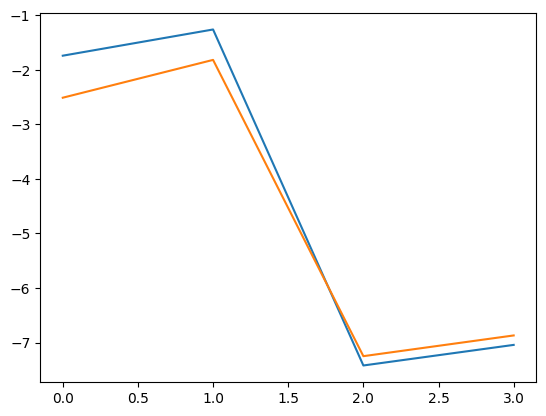

In [14]:
plt.plot(custom_nn.param_search.cv_results_['mean_train_score'])
plt.plot(custom_nn.param_search.cv_results_['mean_test_score'])

In [16]:
custom_nn.save_model('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_nn_DA_CA_NP_SP.pkl')

In [33]:
custom_nn.load_model('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_nn_DA_CA_NP_SP.pkl')

/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/skorch/net.py:2261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuda_attrs = torch.load(f, **l

In [ ]:
# CPU inference / Inferencia en CPU
best_estimator = custom_nn.param_search.best_estimator_
nn_model = best_estimator.set_params(device='cpu')

# Build test features+metadata / Construir features+metadata de test
features_test, metadata_test = nn_model._create_features_metadata(df_X_test[all_columns])
norm_features_test = norm.normalize(features_test)

# MBM aggregated dataset / Dataset agregado de MBM
dataset_test = mbm.data_processing.AggregatedDataset(cfg, features=norm_features_test, metadata=metadata_test, targets=y_test)

dataset_test = [SliceDataset(dataset_test, idx=0), SliceDataset(dataset_test, idx=1)]

# Row preds + ID aggregation / Predicción por fila + agregación por ID
y_pred = nn_model.predict(dataset_test[0])
y_pred_agg = nn_model.aggrPredict(dataset_test[0])

# Align true targets to agg order / Alinear y_true al orden agregado
batchIndex = np.arange(len(y_pred_agg))
y_true = np.array([e for e in dataset_test[1][batchIndex]])

# Scores & metrics / Puntajes y métricas
score = nn_model.score(dataset_test[0], dataset_test[1])
mse, rmse, mae, pearson = nn_model.evalMetrics(y_pred, y_true)

# Build ID-level table / Construir tabla a nivel ID
id = dataset_test[0].dataset.indexToId(batchIndex)
data = {'target': [e[0] for e in dataset_test[1]], 'ID': id, 'pred': y_pred_agg}
grouped_ids = pd.DataFrame(data)



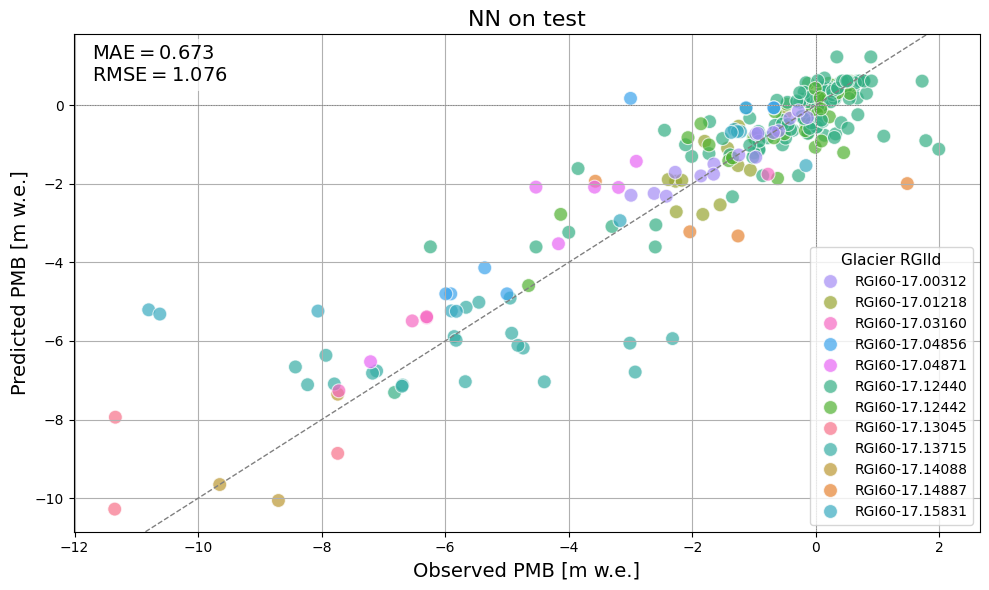

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame with aggregated predictions
# Crear DataFrame con predicciones agregadas
df_pred_nn = pd.DataFrame({
    'ID': id,
    'target': [e[0] for e in dataset_test[1]],
    'pred': y_pred_agg
})

# Get the RGIId associated with each ID from the original df_X_test
# Obtener el RGIId asociado a cada ID desde df_X_test original
# Ensure df_X_test contains 'ID' and 'RGIId' columns
# Asegúrate de que df_X_test contenga las columnas 'ID' y 'RGIId'
id_to_rgi = df_X_test[['ID', 'RGIId']].drop_duplicates().set_index('ID')['RGIId']
df_pred_nn['RGIId'] = df_pred_nn['ID'].map(id_to_rgi)

# Group by ID to get mean target/pred and the first RGIId
# Agrupar por ID y obtener target/pred promedio y el primer RGIId
grouped_ids = df_pred_nn.groupby('ID').agg({
    'target': 'mean',
    'pred': 'mean',
    'RGIId': 'first'
}).reset_index()

# Metrics text for the annotation box
# Texto de métricas para el recuadro de anotación
legend_text = (
    rf"$\mathrm{{MAE}} = {mae:.3f}$" + "\n" +
    rf"$\mathrm{{RMSE}} = {rmse:.3f}$"
)

# Build a color palette per glacier
# Construir una paleta de colores por glaciar
unique_rgi = grouped_ids['RGIId'].nunique()
palette = sns.color_palette("husl", unique_rgi)

# Create the scatter plot
# Crear el diagrama de dispersión
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grouped_ids,
    x='target',
    y='pred',
    hue='RGIId',
    palette=palette,
    s=100,
    alpha=0.7,
    ax=ax
)

# 1:1 diagonal reference line
# Línea de referencia diagonal 1:1
ax.axline((0, 0), slope=1, color='grey', linestyle='--', linewidth=1)

# Baseline axes lines
# Líneas base de los ejes
ax.axvline(0, color="grey", linestyle=":", linewidth=0.7)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.7)

# Labels and title
# Etiquetas y título
ax.set_xlabel('Observed PMB [m w.e.]', fontsize=14)
ax.set_ylabel('Predicted PMB [m w.e.]', fontsize=14)
ax.set_title('NN on test', fontsize=16)

# Show metrics box on the plot
# Mostrar el recuadro de métricas en el gráfico
ax.text(0.02, 0.98, legend_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=14,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Sorted legend by label
# Leyenda ordenada por etiqueta
handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          title='Glacier RGIId', fontsize=10, title_fontsize=11)

# Grid, layout, save, and show
# Cuadrícula, ajuste, guardado y visualización
ax.grid(True)
plt.tight_layout()
plt.savefig("nn_test_performance.png", dpi=300)
plt.show()


Selected regions distribution:
 region
North Patagonian Andes    1307
South Patagonian Andes     637
Central Andes              618
Desert Andes               140

Selected regions ['Desert Andes', 'Central Andes', 'North Patagonian Andes', 'South Patagonian Andes'] — metrics (ID-level):
 {'mse': 1.3330278054160454, 'rmse': 1.1545682333305578, 'mae': 0.7171784439966555, 'pearson': 0.9215602416762537, 'n': 818, 'score': -1.3330277998955726}
✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/plot_selected_regions_NN_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.png


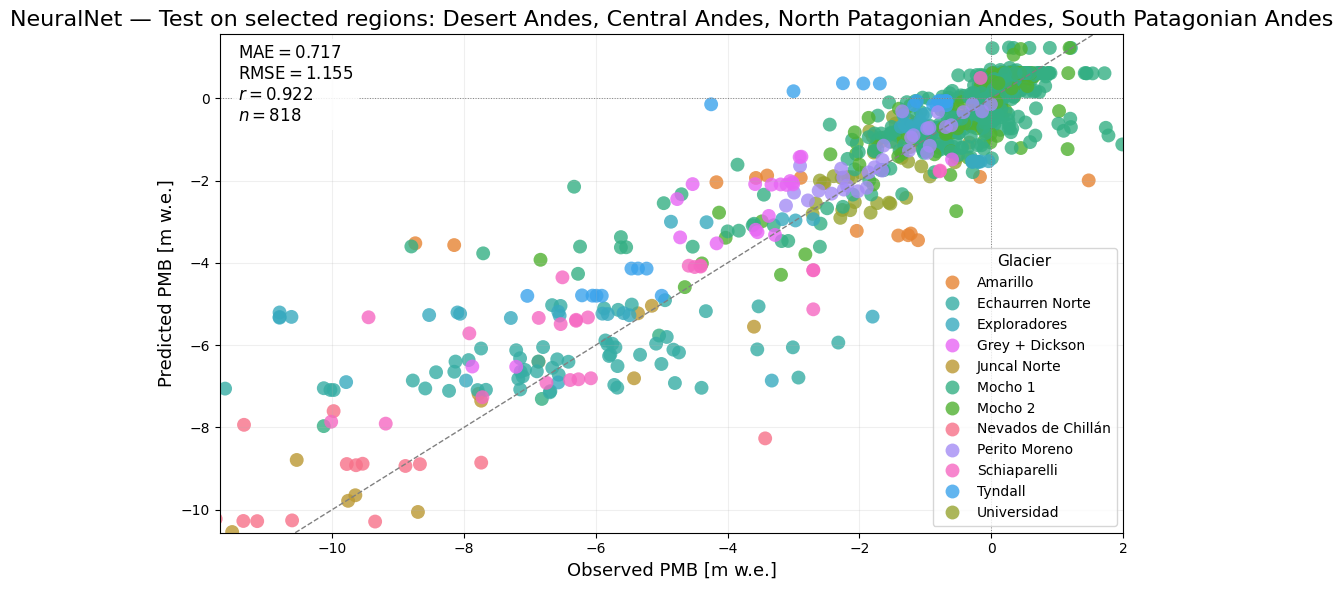

✓ Aggregated-by-ID (combined) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/pred_agg_byID_NN_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.csv
✓ Combined metrics saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/metrics_combined_NN_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.csv
✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/plot_NN_DesertAndes_20250826_172227.png


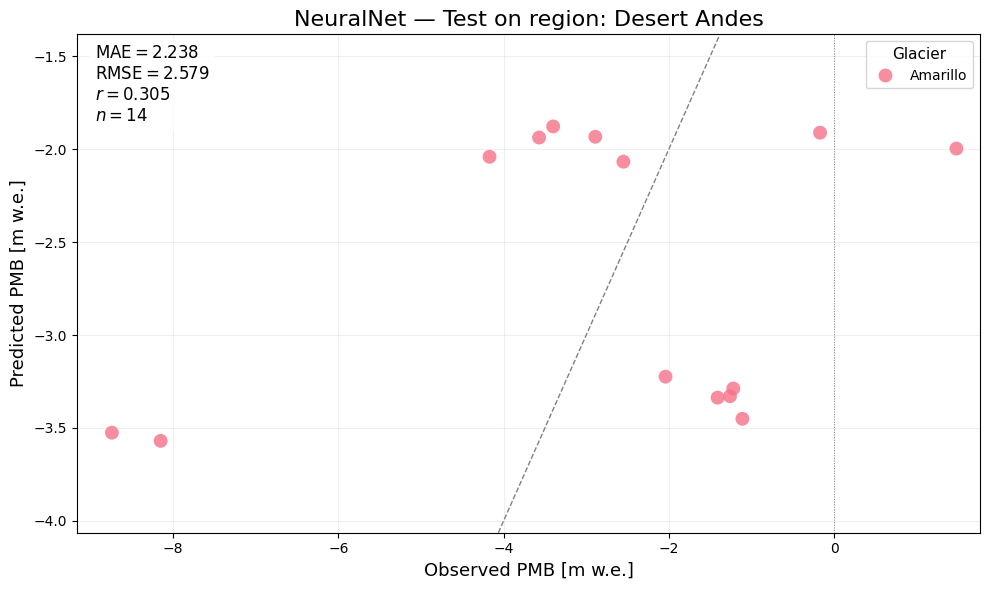

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/plot_NN_CentralAndes_20250826_172227.png


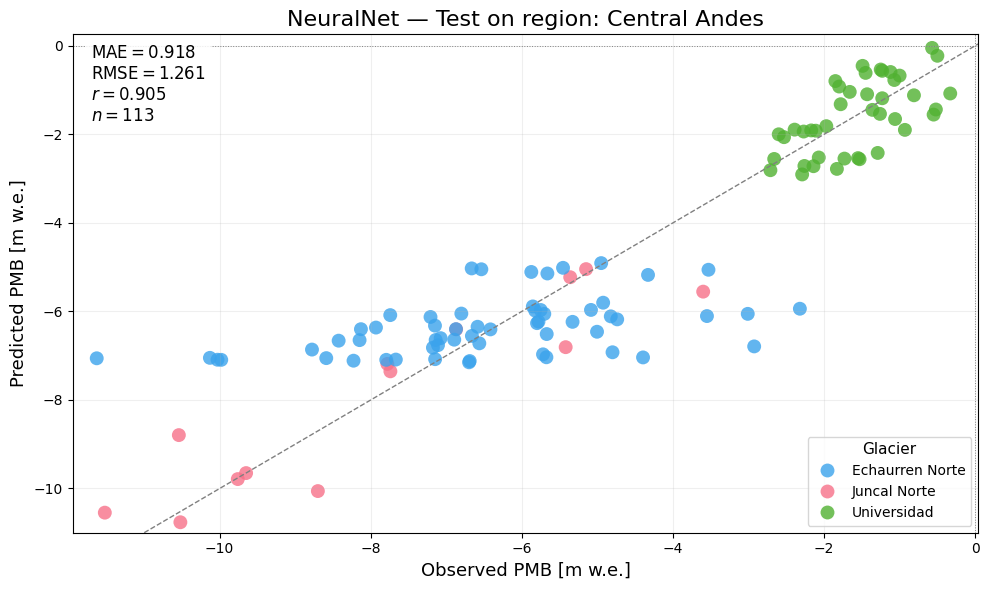

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/plot_NN_NorthPatagonianAndes_20250826_172227.png


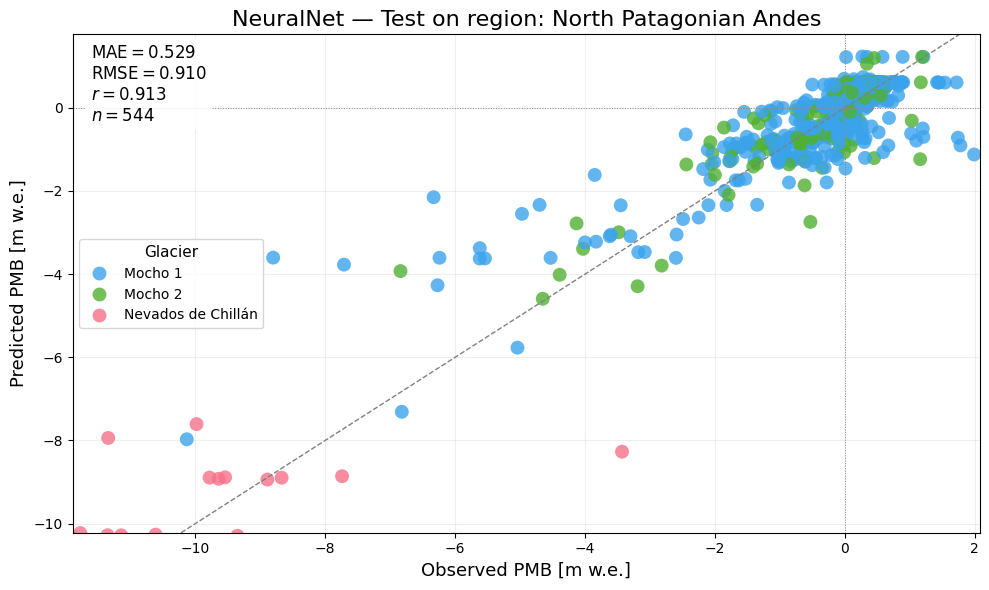

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/plot_NN_SouthPatagonianAndes_20250826_172227.png


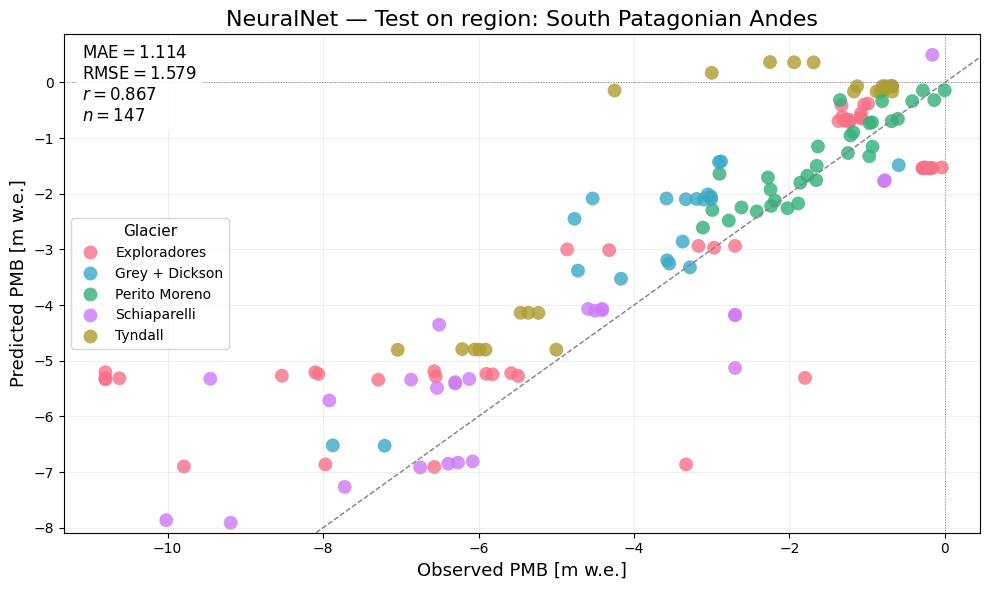


Per-region summary (sorted by RMSE):
                region      mse     rmse      mae  pearson   n     score
North Patagonian Andes 0.828986 0.910487 0.529042 0.912962 544 -0.828986
         Central Andes 1.590060 1.260976 0.918188 0.904759 113 -1.590059
South Patagonian Andes 2.494291 1.579333 1.114098 0.866996 147 -2.494292
          Desert Andes 6.650760 2.578907 2.237524 0.305370  14 -6.650760
✓ Per-region metrics saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/metrics_per_region_NN_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.csv
✓ Aggregated-by-ID (Desert Andes) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/pred_agg_byID_NN_DesertAndes_20250826_172227.csv
✓ Aggregated-by-ID (Central Andes) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/pred_agg_byID_NN_CentralAndes_20250826_1

In [47]:
import os, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Imports for data handling, math, and plotting
# Importaciones para manejo de datos, matemáticas y gráficos

def slugify(s: str) -> str:
    # Safe token for filenames (remove non-alphanumerics)
    # Token seguro para nombres de archivo (elimina no alfanuméricos)
    """Safe token for filenames."""
    return re.sub(r'[^A-Za-z0-9]+', '', s)

def compute_id_level_metrics(y_true, y_pred):
    # Compute MSE/RMSE/MAE/Pearson at ID level, ignoring NaN/Inf
    # Calcula MSE/RMSE/MAE/Pearson a nivel ID, ignorando NaN/Inf
    """Compute MSE/RMSE/MAE/Pearson at ID-level, ignoring NaN/Inf."""
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        raise ValueError("No valid (finite) target/pred pairs to compute metrics.")
    yt = y_true[mask]
    yp = y_pred[mask]
    mse = float(np.mean((yt - yp) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(yt - yp)))
    pearson = float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 else np.nan
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'pearson': pearson, 'n': int(len(yt))}

def plot_obs_vs_pred_idlevel(grouped,
                             rgi_to_name=None,
                             title='Observed vs Predicted (ID level)',
                             annotate_metrics=None,
                             xlim=None, ylim=None,
                             savepath=None):
    # 1:1 scatter at ID level using ['ID','target','pred','RGIId']; hues by glacier
    # Dispersión 1:1 a nivel ID con ['ID','target','pred','RGIId']; color por glaciar
    """
    Scatter 1:1 at ID level using columns: ['ID','target','pred','RGIId'].
    Colors by glacier (RGI mapped to readable name if provided).
    """
    required_cols = {'ID', 'target', 'pred', 'RGIId'}
    # Validate required columns exist
    # Validar que existan las columnas requeridas
    missing = required_cols - set(grouped.columns)
    if missing:
        raise KeyError(f"Missing columns in grouped: {sorted(missing)}")

    df = grouped.copy()
    rgi_to_name = rgi_to_name or {}
    # Map RGIId -> readable glacier name
    # Mapear RGIId -> nombre legible del glaciar
    df['GlacierName'] = df['RGIId'].map(rgi_to_name).fillna(df['RGIId'])

    # Drop rows with NaN/Inf in target/pred for clean plotting
    # Eliminar filas con NaN/Inf en target/pred para un gráfico limpio
    m = np.isfinite(df['target'].to_numpy()) & np.isfinite(df['pred'].to_numpy())
    dropped = (~m).sum()
    if dropped:
        print(f"⚠️ Dropping {dropped} rows with NaN/Inf in target/pred for plotting.")
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot after dropping NaN/Inf.")

    # Auto choose limits from 1–99 percentiles with small padding
    # Elegir límites automáticamente con percentiles 1–99 y pequeño margen
    if xlim is None:
        qx = np.nanpercentile(df['target'], [1, 99])
        pad = max(0.5, 0.05 * (qx[1] - qx[0] + 1e-6))
        xlim = (qx[0] - pad, qx[1] + pad)
    if ylim is None:
        qy = np.nanpercentile(df['pred'], [1, 99])
        pad = max(0.5, 0.05 * (qy[1] - qy[0] + 1e-6))
        ylim = (qy[0] - pad, qy[1] + pad)

    # Color palette per glacier
    # Paleta de colores por glaciar
    n_glac = df['GlacierName'].nunique()
    palette = sns.color_palette("husl", n_glac if n_glac > 0 else 1)

    # Build the scatter plot
    # Construir el diagrama de dispersión
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(
        data=df, x='target', y='pred', hue='GlacierName',
        palette=palette, s=100, alpha=0.8, ax=ax, edgecolor='none'
    )

    # 1:1 diagonal and axis helpers
    # Diagonal 1:1 y líneas guía de ejes
    ax.axline((0, 0), slope=1, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle=':', linewidth=0.7)
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.7)

    # Labels, title, and limits
    # Etiquetas, título y límites
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Observed PMB [m w.e.]', fontsize=13)
    ax.set_ylabel('Predicted PMB [m w.e.]', fontsize=13)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # Metrics box (compute if not provided)
    # Recuadro de métricas (calcular si no se provee)
    if annotate_metrics is None:
        annotate_metrics = compute_id_level_metrics(df['target'], df['pred'])
    lines = []
    if np.isfinite(annotate_metrics.get('mae', np.nan)):
        lines.append(rf"$\mathrm{{MAE}}={annotate_metrics['mae']:.3f}$")
    if np.isfinite(annotate_metrics.get('rmse', np.nan)):
        lines.append(rf"$\mathrm{{RMSE}}={annotate_metrics['rmse']:.3f}$")
    if np.isfinite(annotate_metrics.get('pearson', np.nan)):
        lines.append(rf"$r={annotate_metrics['pearson']:.3f}$")
    if 'n' in annotate_metrics:
        lines.append(rf"$n={annotate_metrics['n']}$")
    if lines:
        ax.text(0.02, 0.98, "\n".join(lines),
                transform=ax.transAxes, va='top', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

    # Sort legend alphabetically by label
    # Ordenar la leyenda alfabéticamente por etiqueta
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        pairs = sorted(zip(labels, handles), key=lambda t: t[0])
        labels_sorted, handles_sorted = zip(*pairs)
        ax.legend(handles_sorted, labels_sorted, title='Glacier',
                  fontsize=10, title_fontsize=11, loc='best', frameon=True)

    # Grid, layout, optional save
    # Cuadrícula, ajuste de diseño, guardado opcional
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Plot saved to: {savepath}")
    plt.show()
    return fig, ax

def build_nn_test_from_regions(data, regions, all_columns, nn_model, norm, cfg):
    # Filter DF by regions, build features/metadata, normalize, return df + datasets
    # Filtra DF por regiones, construye features/metadatos, normaliza, retorna df + datasets
    """
    Filter `data` by `regions`, build features/metadata, normalize, and return:
      df_sel, X_sel, y_sel, ds_pair=[X_dataset, y_dataset]
    """
    from skorch.helper import SliceDataset
    # Validate inputs and reconstruct 'region' if missing
    # Validar entradas y reconstruir 'region' si falta
    if not isinstance(data, pd.DataFrame):
        raise TypeError("`data` must be a pandas.DataFrame (was overwritten elsewhere).")
    if 'region' not in data.columns:
        if 'POINT_LAT' not in data.columns:
            raise KeyError("Missing 'region' and 'POINT_LAT' to reconstruct it.")
        data = data.copy()
        # Create region from POINT_LAT using your classify_region
        # Crear region desde POINT_LAT usando tu classify_region
        data['region'] = data['POINT_LAT'].apply(classify_region)

    # Build selection mask for requested regions
    # Construir máscara de selección para las regiones solicitadas
    wanted = {r.strip() for r in ([regions] if isinstance(regions, str) else regions)}
    df_sel = data[data['region'].astype(str).str.strip().isin(wanted)].copy()
    if df_sel.empty:
        raise ValueError(f"No rows found for selected regions: {sorted(wanted)}")

    # Extract X/y with columns the model expects
    # Extraer X/y con las columnas que espera el modelo
    X_sel = df_sel[all_columns]
    y_sel = df_sel['POINT_BALANCE'].values

    # Features + metadata from model helper, then normalize features
    # Features + metadatos desde el helper del modelo, luego normalizar features
    feats, meta = nn_model._create_features_metadata(X_sel)
    norm_feats = norm.normalize(feats)

    # Build aggregated dataset views
    # Construir vistas de dataset agregado
    ds = mbm.data_processing.AggregatedDataset(cfg, features=norm_feats, metadata=meta, targets=y_sel)
    ds_pair = [SliceDataset(ds, idx=0), SliceDataset(ds, idx=1)]
    return df_sel, X_sel, y_sel, ds_pair

def predict_and_aggregate_nn(nn_model, ds_pair, X_sel):
    # Predict row-wise, aggregate per ID, align targets and attach glacier code
    # Predecir por fila, agregar por ID, alinear objetivos y anexar código de glaciar
    """
    Predict and aggregate by ID (aligned order). Returns:
      y_pred_id: (N,) aggregated predictions per ID
      y_true_id: (N,) aggregated targets per ID (nanmean)
      grouped  : DataFrame ['ID','target','pred','RGIId'] at ID level
    """
    # Get ID-level predictions
    # Obtener predicciones a nivel ID
    y_pred_id = nn_model.aggrPredict(ds_pair[0])
    y_pred_id = np.asarray(y_pred_id).reshape(-1)

    # Reduce true targets to one scalar per ID (nanmean) in same order
    # Reducir objetivos verdaderos a un escalar por ID (nanmean) en el mismo orden
    batchIndex = np.arange(len(y_pred_id))
    y_true_id = np.array([
        np.nanmean(np.asarray(e).reshape(-1))
        for e in ds_pair[1][batchIndex]
    ]).reshape(-1)

    # Retrieve IDs in the aggregated order
    # Recuperar IDs en el orden agregado
    ids_aggr = ds_pair[0].dataset.indexToId(batchIndex)
    ids_aggr = np.asarray(ids_aggr).reshape(-1)

    # Sanity check on lengths
    # Verificación de longitudes
    if not (len(ids_aggr) == len(y_pred_id) == len(y_true_id)):
        raise ValueError(
            f"Length mismatch: ids={len(ids_aggr)}, pred={len(y_pred_id)}, true={len(y_true_id)}"
        )

    # Build aggregated-by-ID table
    # Construir tabla agregada por ID
    grouped = pd.DataFrame({
        'ID': ids_aggr,
        'pred': y_pred_id,
        'target': y_true_id
    })

    # Attach first RGIId per ID from X_sel
    # Anexar primer RGIId por ID desde X_sel
    df_glac = X_sel.groupby('ID', as_index=False)['RGIId'].first()
    grouped = grouped.merge(df_glac, on='ID', how='left')

    return y_pred_id, y_true_id, grouped

# ---------- config for outputs & regions ----------
# Paths and folders for outputs and figures
# Rutas y carpetas para salidas y figuras
out_dir  = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP'
fig_path = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

# Region set to analyze (must match classify_region)
# Conjunto de regiones a analizar (debe coincidir con classify_region)
analyze_regions = ["Desert Andes", "Central Andes", "North Patagonian Andes", "South Patagonian Andes"]

# Optional map RGI -> readable glacier names
# Mapa opcional RGI -> nombres legibles de glaciares
rgi_to_name = {
    "RGI60-17.12440": "Mocho 1",
    "RGI60-17.12442": "Mocho 2",
    "RGI60-17.13045": "Nevados de Chillán",
    "RGI60-17.01218": "Universidad",
    "RGI60-17.14088": "Juncal Norte",
    "RGI60-17.14887": "Amarillo",
    "RGI60-17.13715": "Echaurren Norte",
    "RGI60-17.15831": "Exploradores",
    "RGI60-17.00312": "Perito Moreno",
    "RGI60-17.04871": "Grey + Dickson",
    "RGI60-17.04856": "Tyndall",
    "RGI60-17.03160": "Schiaparelli"
}

from datetime import datetime
# Timestamp and region tag for filenames
# Marca de tiempo y etiqueta de regiones para nombres de archivo
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
regions_tag = "_".join(slugify(r) for r in analyze_regions)

# ---------- combined (all selected regions) ----------
# Build test subset, features, and datasets for all selected regions
# Construir subconjunto de prueba, features y datasets para todas las regiones seleccionadas
df_sel, X_sel, y_sel, ds_pair = build_nn_test_from_regions(
    data=data_df,               # <- master DF
    regions=analyze_regions,
    all_columns=all_columns,
    nn_model=nn_model,
    norm=norm,
    cfg=cfg
)
print("Selected regions distribution:\n", df_sel['region'].value_counts().to_string())

# Predict and aggregate at ID level
# Predecir y agregar a nivel ID
y_pred_id, y_true_id, grouped_sel = predict_and_aggregate_nn(
    nn_model=nn_model, ds_pair=ds_pair, X_sel=X_sel
)

# Compute ID-level metrics (and optional model score)
# Calcular métricas a nivel ID (y puntaje opcional del modelo)
metrics_sel = compute_id_level_metrics(grouped_sel['target'], grouped_sel['pred'])
try:
    score_combined = float(nn_model.score(ds_pair[0], ds_pair[1]))
    metrics_sel['score'] = score_combined
except Exception:
    pass
print(f"\nSelected regions {analyze_regions} — metrics (ID-level):\n", metrics_sel)

# Plot combined 1:1 and save
# Graficar 1:1 combinado y guardar
combined_plot_path = os.path.join(fig_path, f'plot_selected_regions_NN_{regions_tag}_{ts}.png')
plot_obs_vs_pred_idlevel(
    grouped_sel,
    rgi_to_name=rgi_to_name,
    title=f'NeuralNet — Test on selected regions: {", ".join(analyze_regions)}',
    annotate_metrics=metrics_sel,
    savepath=combined_plot_path
)

# Export combined aggregated predictions and metrics
# Exportar predicciones agregadas combinadas y métricas
path_agg_combined = os.path.join(out_dir, f'pred_agg_byID_NN_{regions_tag}_{ts}.csv')
grouped_sel.to_csv(path_agg_combined, index=False)
print(f'✓ Aggregated-by-ID (combined) saved to: {path_agg_combined}')

df_metrics_combined = pd.DataFrame([{**metrics_sel, 'regions': ", ".join(analyze_regions), 'timestamp': ts}])
path_metrics_combined = os.path.join(out_dir, f'metrics_combined_NN_{regions_tag}_{ts}.csv')
df_metrics_combined.to_csv(path_metrics_combined, index=False)
print(f'✓ Combined metrics saved to: {path_metrics_combined}')

# ---------- per-region loop (comparative analysis) ----------
# Loop through regions to compute per-region plots, metrics, and exports
# Recorrer regiones para calcular gráficos, métricas y exportaciones por región
summary_rows = []
per_region_agg_outputs = []

for reg in analyze_regions:
    # Build region-specific datasets
    # Construir datasets específicos por región
    df_r, X_r, y_r, ds_r = build_nn_test_from_regions(
        data=data_df, regions=reg, all_columns=all_columns,
        nn_model=nn_model, norm=norm, cfg=cfg
    )
    # Predict and aggregate for region
    # Predecir y agregar para la región
    y_pred_id_r, y_true_id_r, grouped_r = predict_and_aggregate_nn(
        nn_model=nn_model, ds_pair=ds_r, X_sel=X_r
    )
    # Compute region metrics (+ optional score)
    # Calcular métricas de la región (+ puntaje opcional)
    metrics_r = compute_id_level_metrics(grouped_r['target'], grouped_r['pred'])
    try:
        metrics_r['score'] = float(nn_model.score(ds_r[0], ds_r[1]))
    except Exception:
        pass

    # Collect summary and keep aggregated outputs
    # Recopilar resumen y conservar salidas agregadas
    summary_rows.append({'region': reg, **metrics_r})
    per_region_agg_outputs.append((reg, grouped_r))

    # Plot and save per-region 1:1
    # Graficar y guardar 1:1 por región
    region_plot_path = os.path.join(fig_path, f'plot_NN_{slugify(reg)}_{ts}.png')
    plot_obs_vs_pred_idlevel(
        grouped_r,
        rgi_to_name=rgi_to_name,
        title=f'NeuralNet — Test on region: {reg}',
        annotate_metrics=metrics_r,
        savepath=region_plot_path
    )

# Build and export per-region summary table
# Construir y exportar tabla resumen por región
if summary_rows:
    df_summary = pd.DataFrame(summary_rows).sort_values('rmse')
    print("\nPer-region summary (sorted by RMSE):")
    print(df_summary.to_string(index=False))
    path_summary = os.path.join(out_dir, f'metrics_per_region_NN_{regions_tag}_{ts}.csv')
    df_summary.to_csv(path_summary, index=False)
    print(f'✓ Per-region metrics saved to: {path_summary}')

# Export aggregated-by-ID CSV for each region
# Exportar CSV agregado por ID para cada región
for reg, grouped_r in per_region_agg_outputs:
    reg_tag = slugify(reg)
    path_agg_reg = os.path.join(out_dir, f'pred_agg_byID_NN_{reg_tag}_{ts}.csv')
    grouped_r.to_csv(path_agg_reg, index=False)
    print(f'✓ Aggregated-by-ID ({reg}) saved to: {path_agg_reg}')


✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/res_vs_pred_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.png


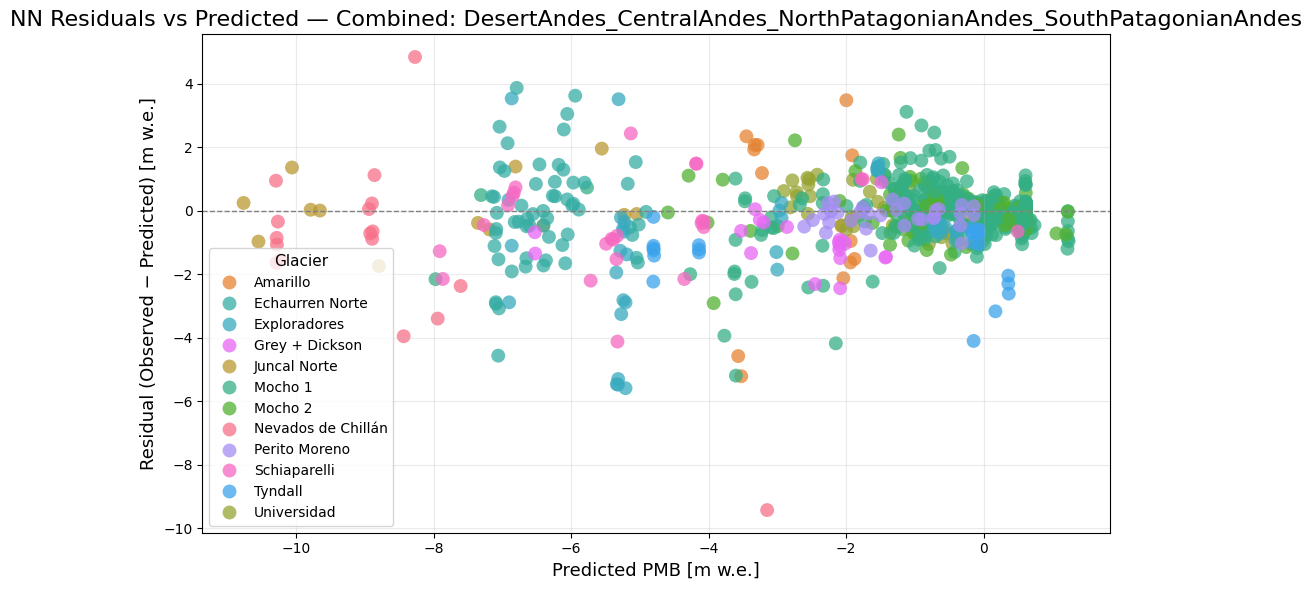

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/residual_box_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.png


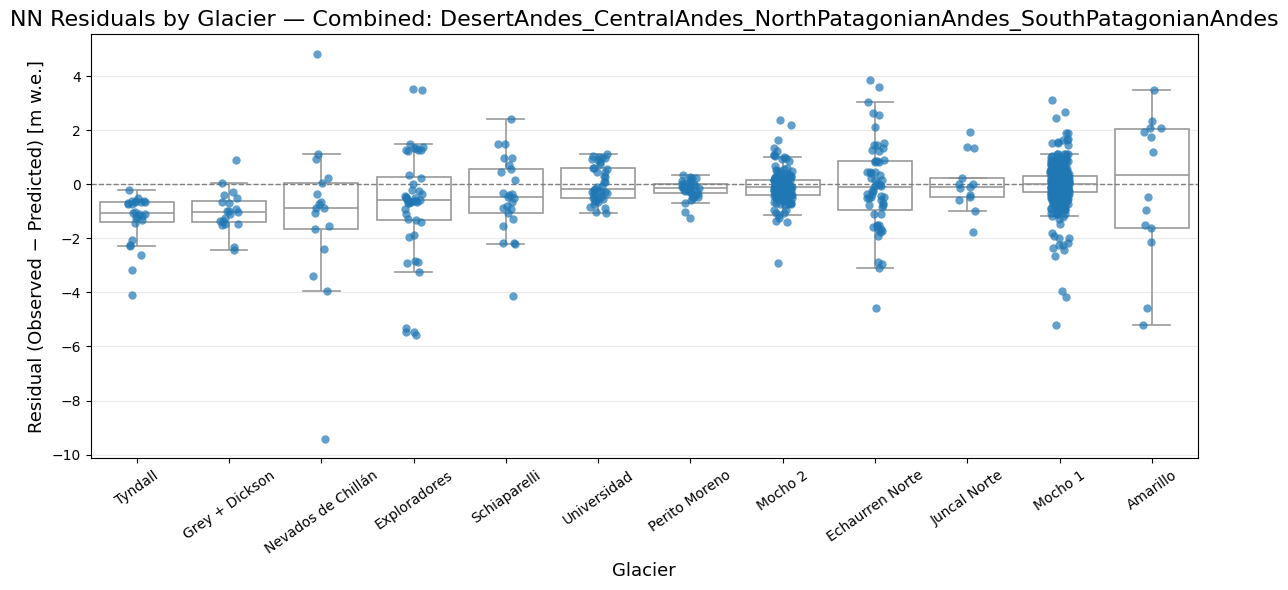

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_hist_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.png


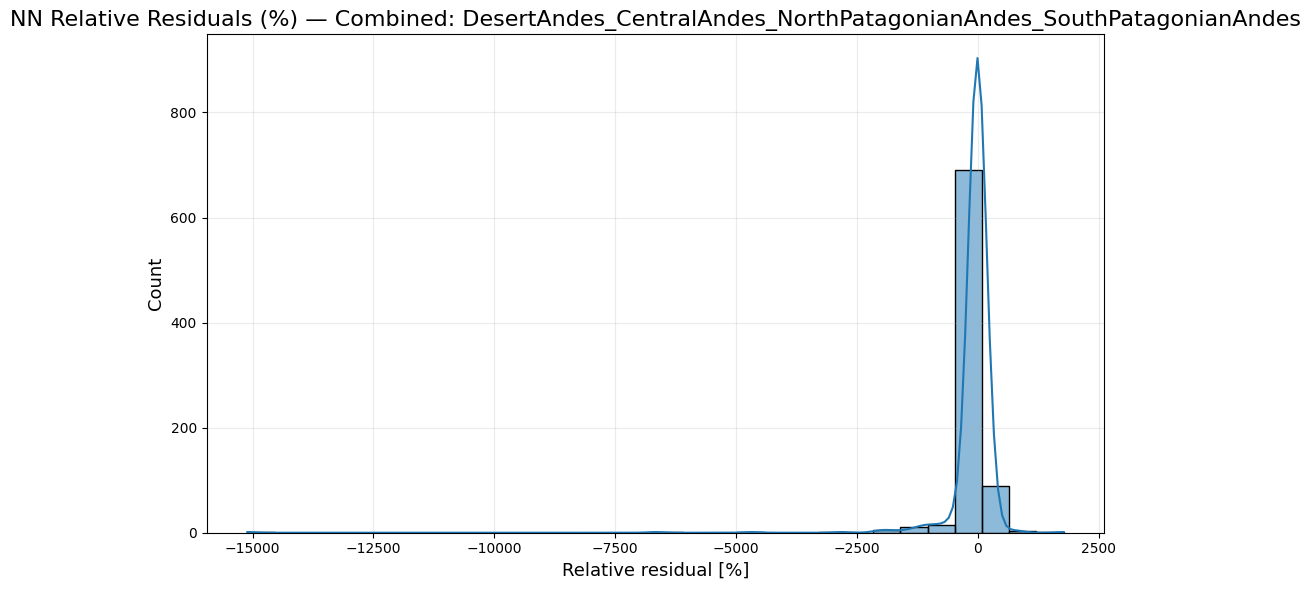

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_box_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.png


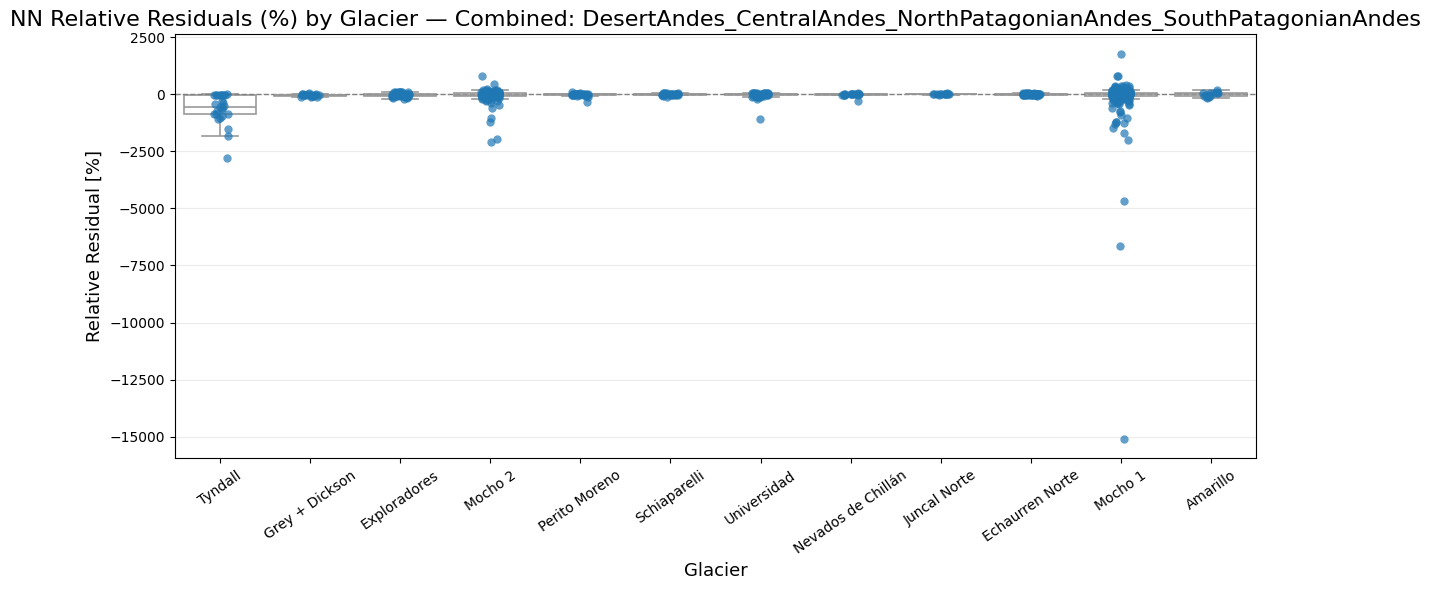

✓ Summary (combined) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/summary_relres_by_glacier_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.csv
✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/res_vs_pred_DesertAndes_20250826_172227.png


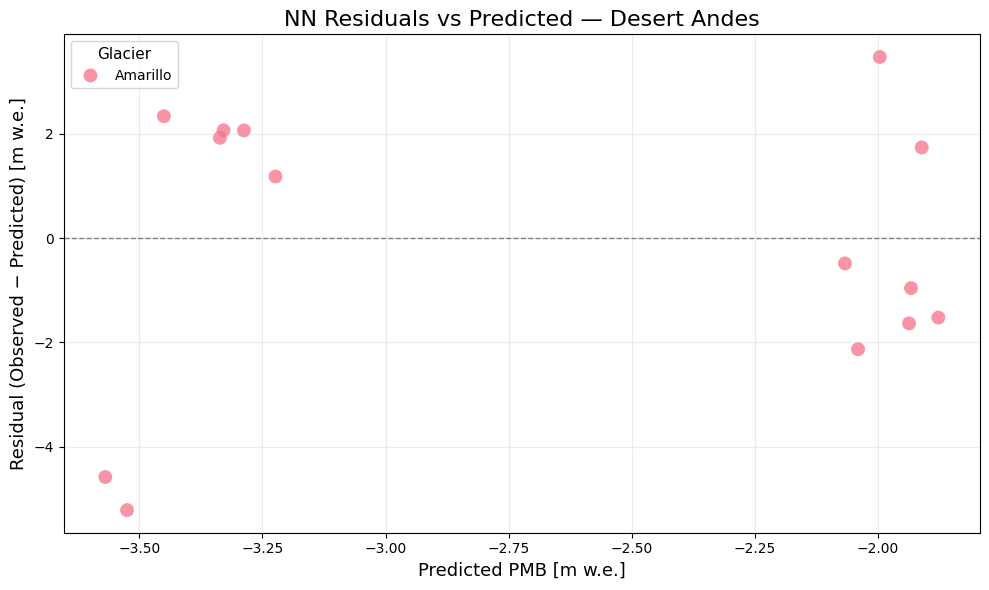

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/residual_box_DesertAndes_20250826_172227.png


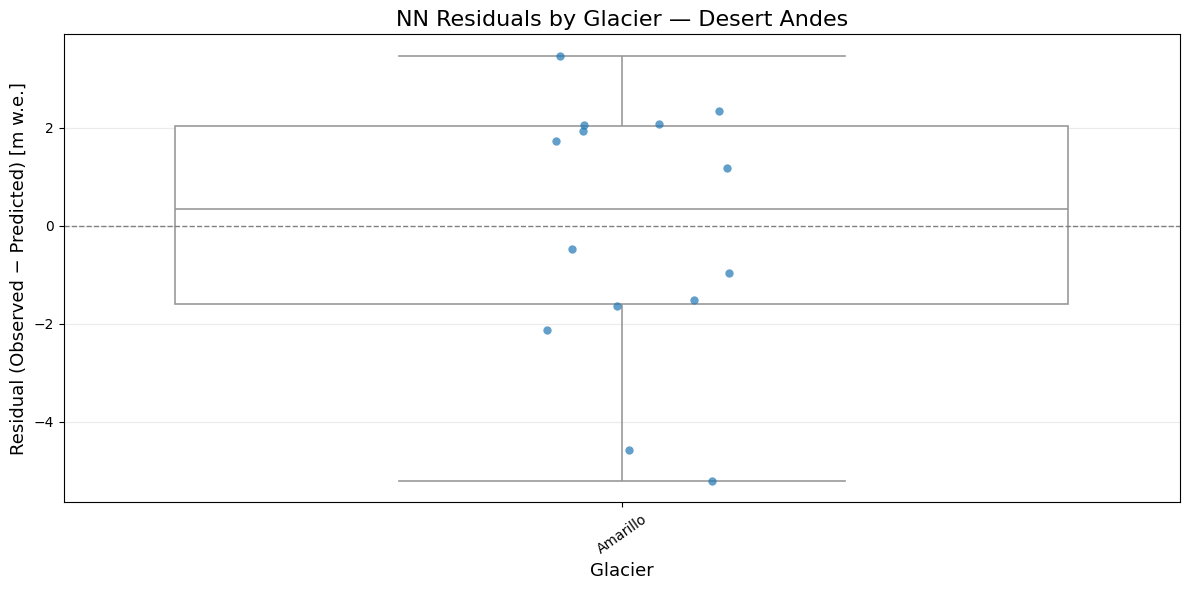

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_hist_DesertAndes_20250826_172227.png


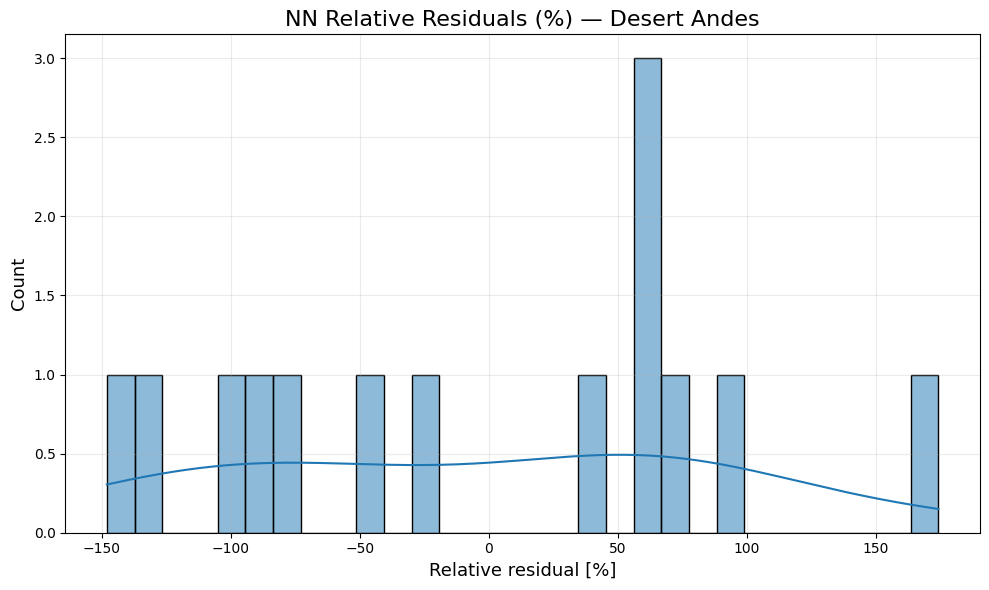

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_box_DesertAndes_20250826_172227.png


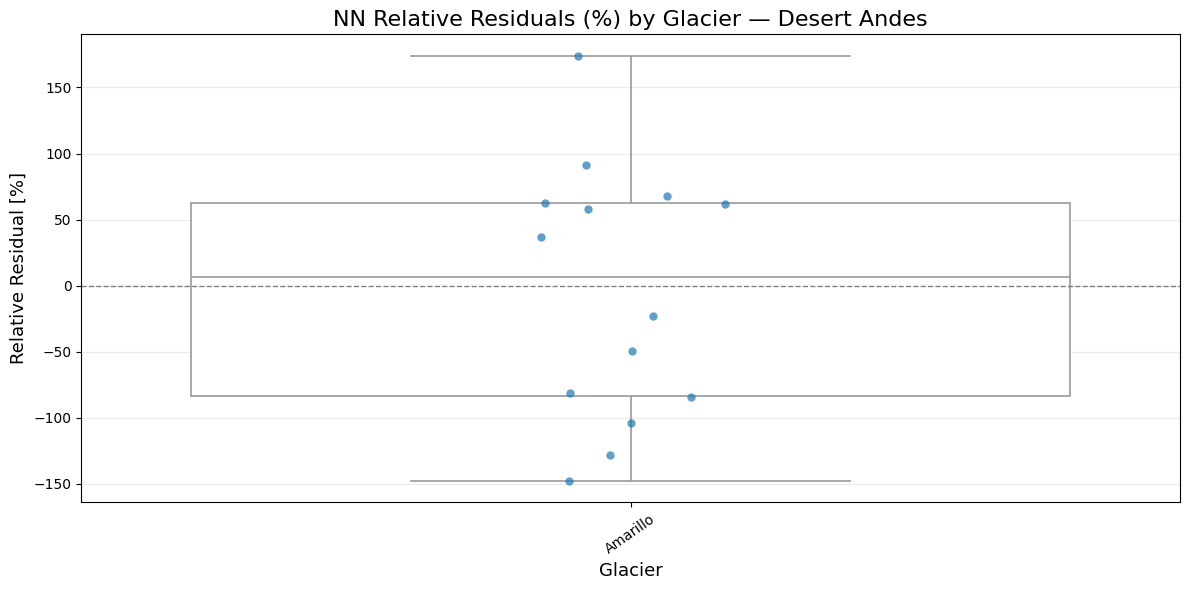

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/res_vs_pred_CentralAndes_20250826_172227.png


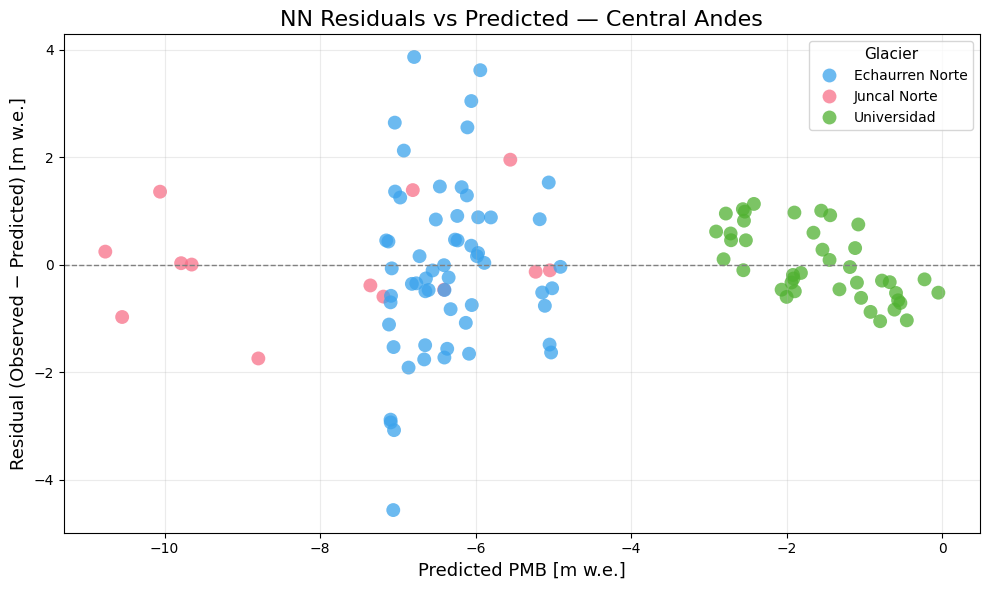

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/residual_box_CentralAndes_20250826_172227.png


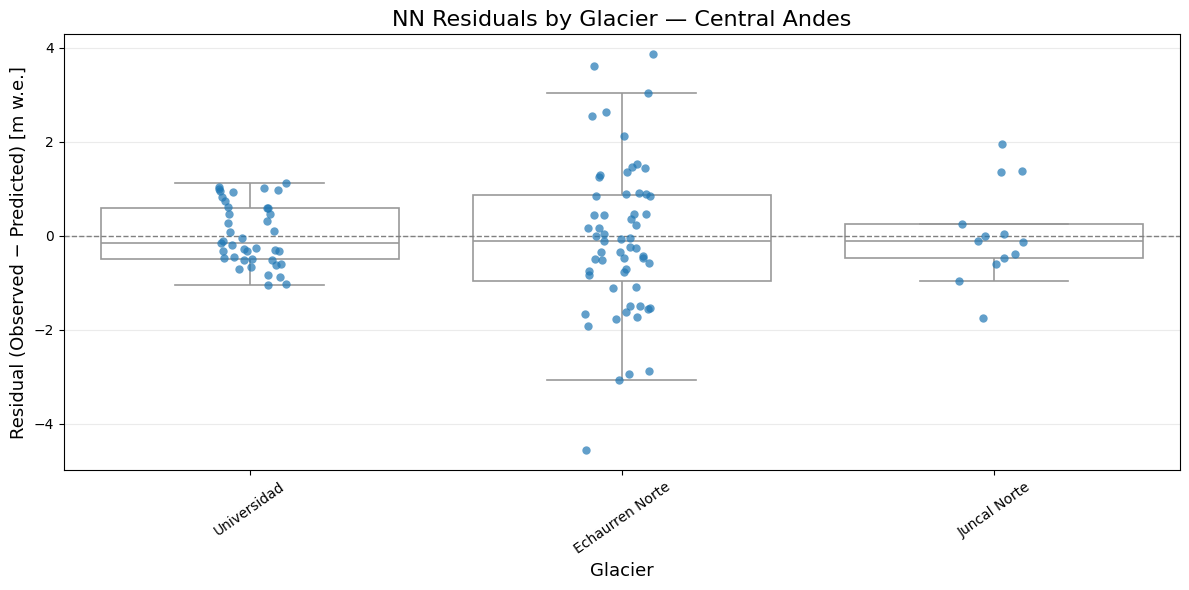

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_hist_CentralAndes_20250826_172227.png


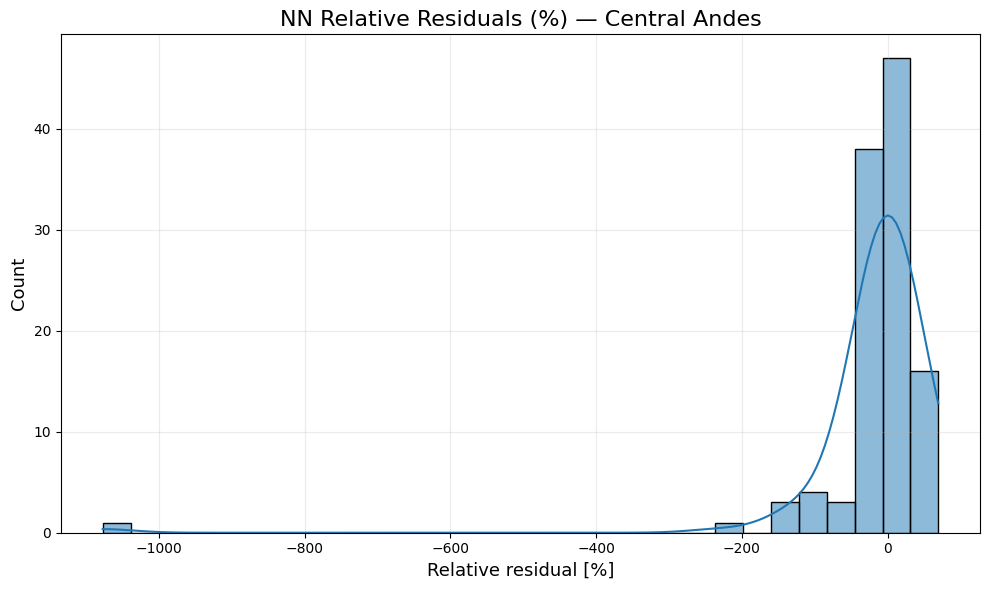

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_box_CentralAndes_20250826_172227.png


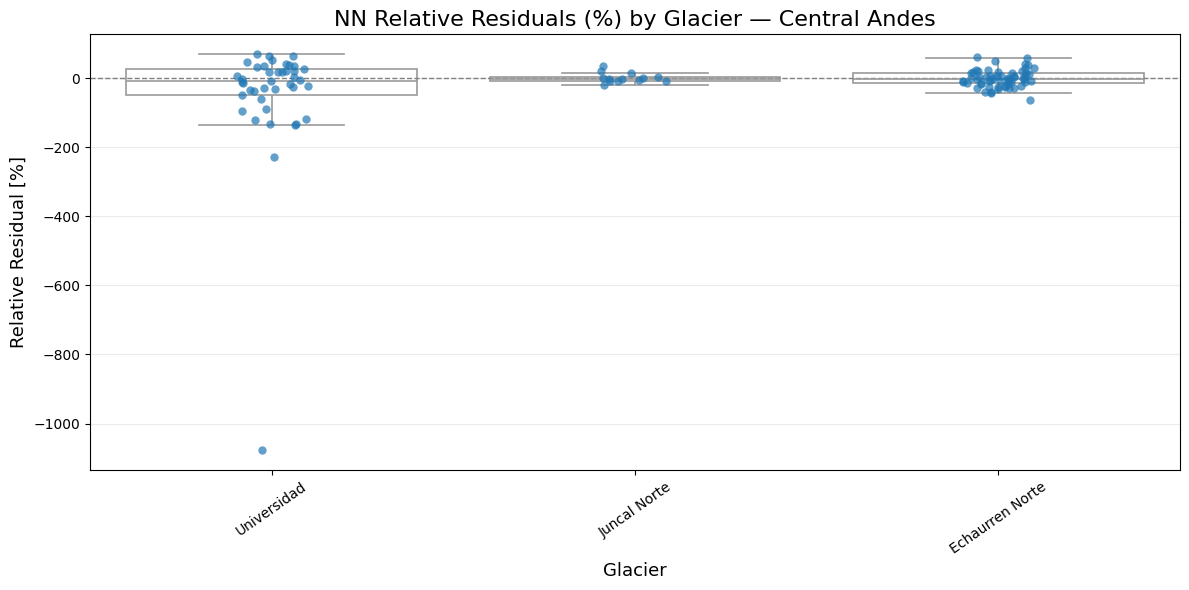

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/res_vs_pred_NorthPatagonianAndes_20250826_172227.png


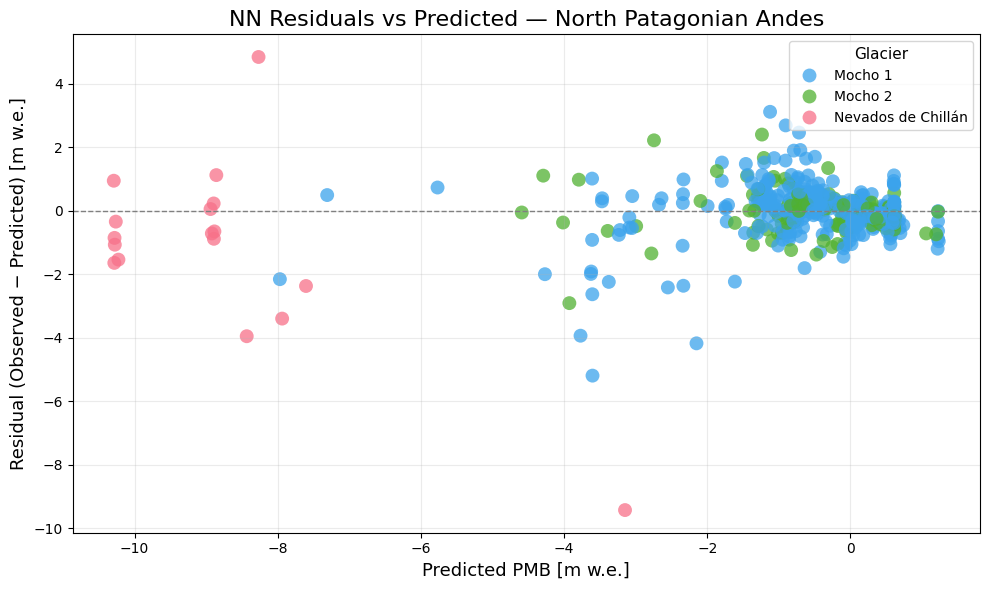

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/residual_box_NorthPatagonianAndes_20250826_172227.png


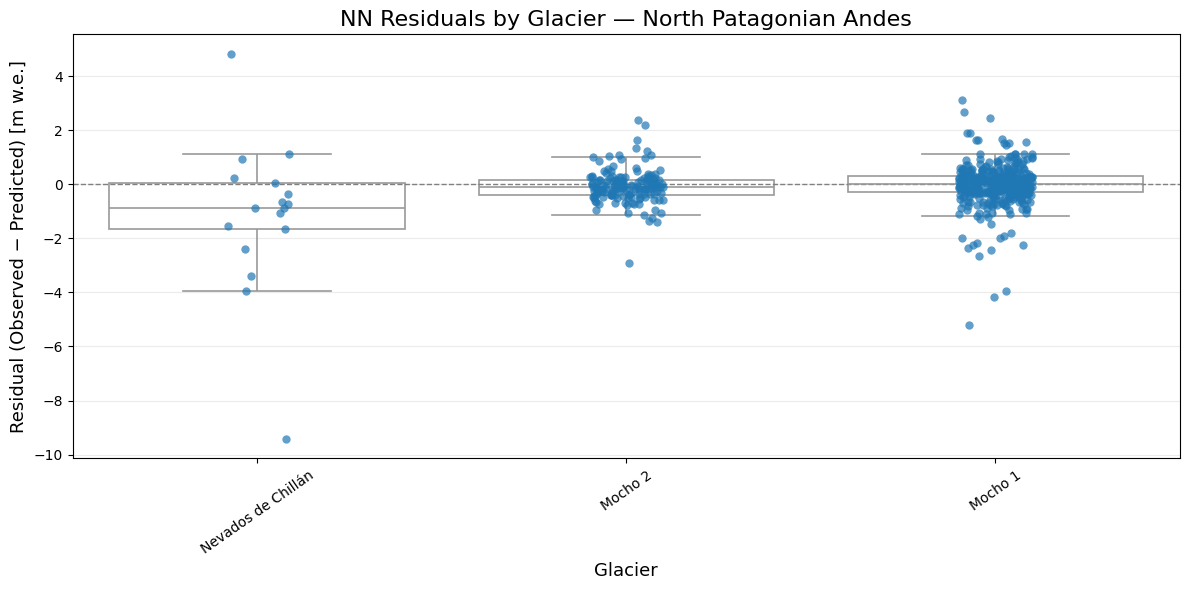

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_hist_NorthPatagonianAndes_20250826_172227.png


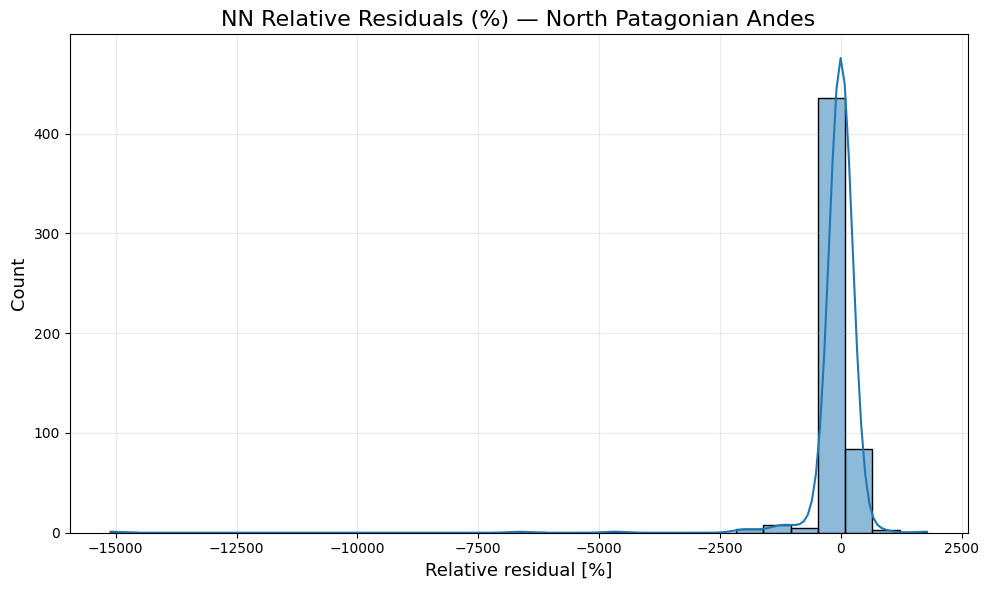

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_box_NorthPatagonianAndes_20250826_172227.png


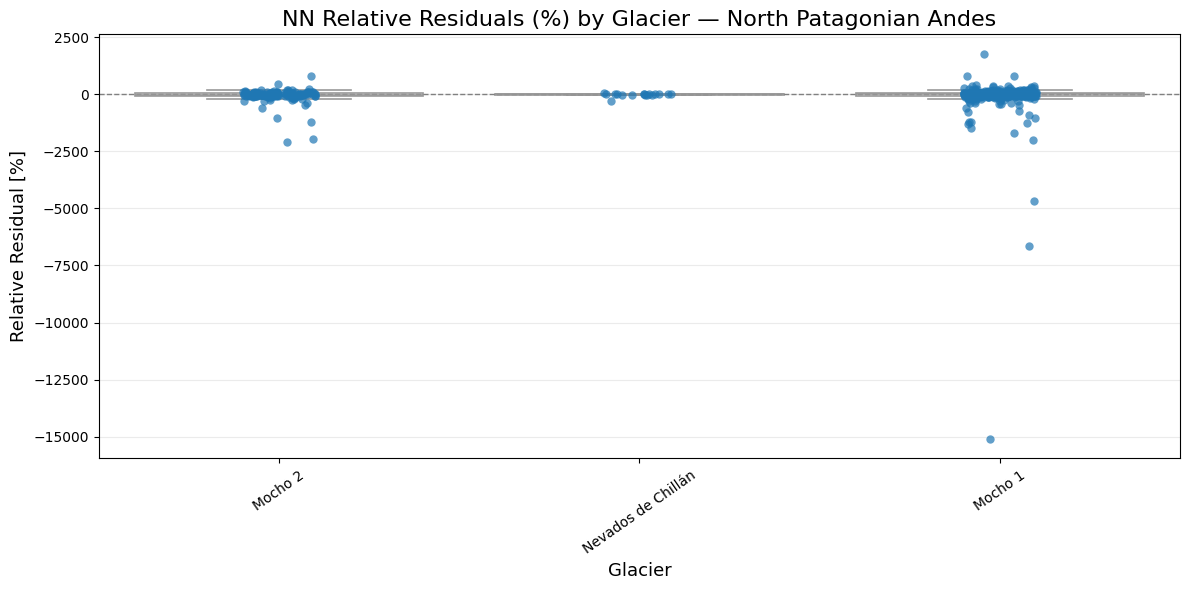

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/res_vs_pred_SouthPatagonianAndes_20250826_172227.png


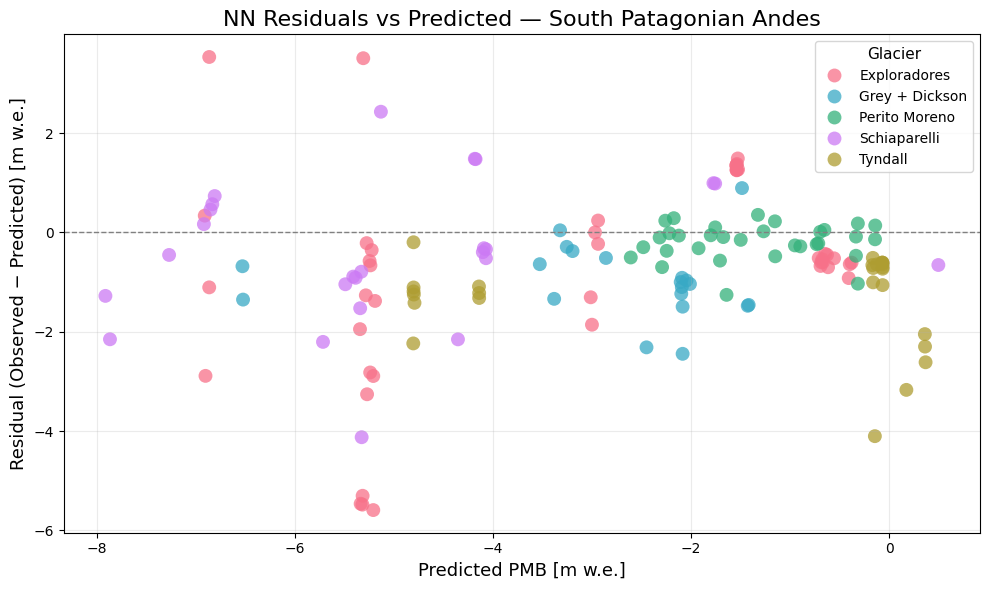

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/residual_box_SouthPatagonianAndes_20250826_172227.png


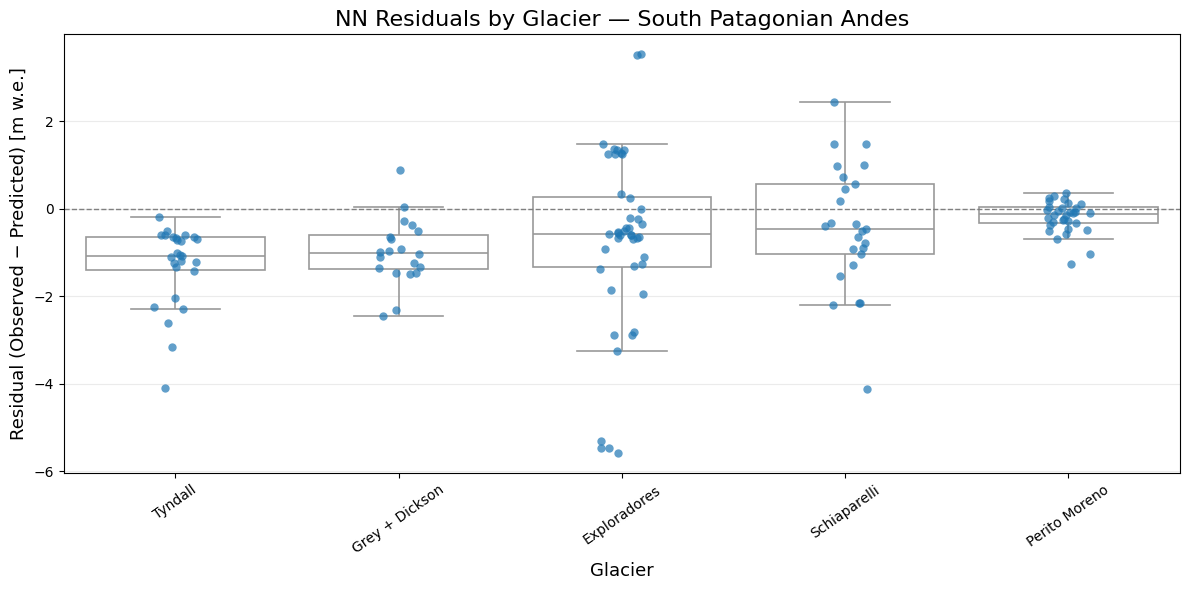

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_hist_SouthPatagonianAndes_20250826_172227.png


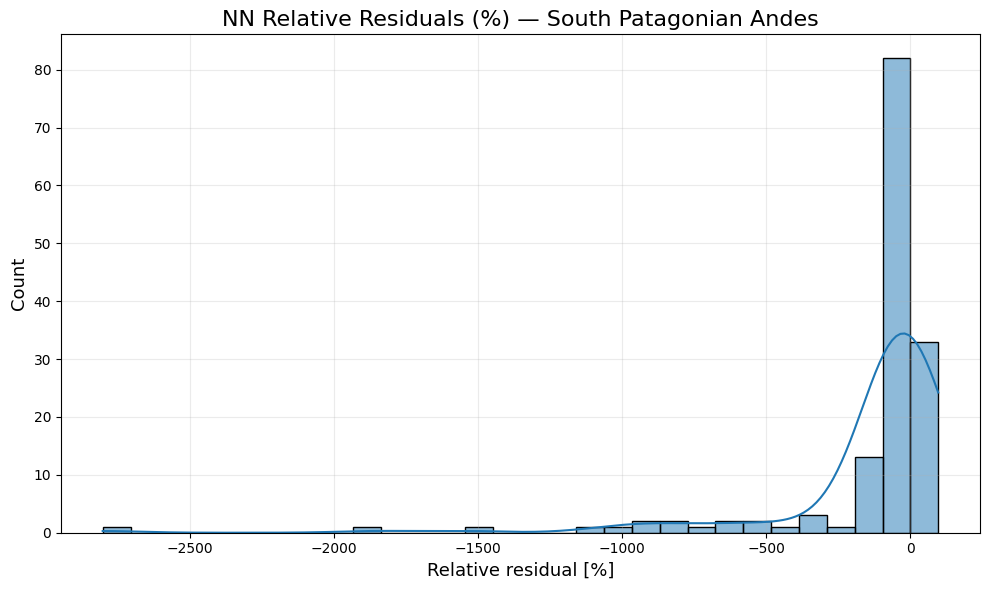

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/figs/DA_CA_NP_SP/relres_box_SouthPatagonianAndes_20250826_172227.png


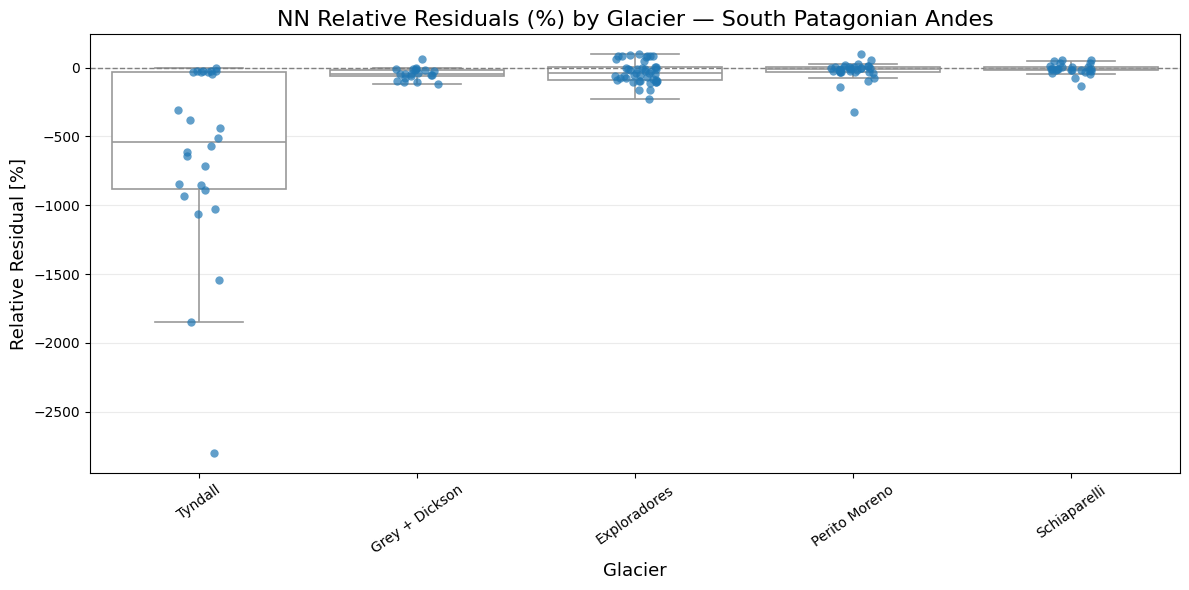

✓ Per-region glacier summaries saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations_nn/DA_CA_NP_SP/summary_relres_by_glacier_per_region_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250826_172227.csv


In [48]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Core imports for data handling and plotting
# Importaciones básicas para manejo de datos y gráficos

# ============================================================
# Utils
# Utilidades
# ============================================================
def ensure_glacier_name(df, rgi_to_name=None, rgi_col='RGIId', out_col='GlacierName'):
    # Map RGIId -> readable glacier name; create/update 'GlacierName'
    # Mapear RGIId -> nombre legible de glaciar; crear/actualizar 'GlacierName'
    """Crea/actualiza la columna GlacierName mapeando RGIId -> nombre legible."""
    out = df.copy()
    rgi_to_name = rgi_to_name or {}
    if rgi_col not in out.columns:
        raise KeyError(f"Missing column '{rgi_col}' in dataframe.")
    out[out_col] = out[rgi_col].map(rgi_to_name).fillna(out[rgi_col])
    return out

def _finite_mask(*arrays):
    # Build a boolean mask that is True only where all arrays are finite
    # Construir una máscara booleana True solo donde todos los arreglos son finitos
    masks = [(np.isfinite(np.asarray(a))) for a in arrays]
    m = masks[0]
    for mm in masks[1:]:
        m = m & mm
    return m

# ============================================================
# Residual columns (ID-level)
# Columnas de residuales (nivel ID)
# ============================================================
def add_residual_columns(df, target_col='target', pred_col='pred', rel_den='pred'):
    # Add residual and % relative residual using |pred| or |target| as denominator
    # Agregar residual y residual relativo % usando |pred| o |target| como denominador
    """
    Agrega:
      - residual = target - pred
      - rel_residual_pct = 100 * residual / |denominador|
    rel_den en {'pred','target'} define el denominador relativo.
    """
    out = df.copy()
    if target_col not in out.columns or pred_col not in out.columns:
        raise KeyError(f"'{target_col}' or '{pred_col}' not in dataframe.")
    out['residual'] = out[target_col] - out[pred_col]

    eps = 1e-9
    if rel_den == 'pred':
        base = out[pred_col].to_numpy(dtype=float)
    elif rel_den == 'target':
        base = out[target_col].to_numpy(dtype=float)
    else:
        raise ValueError("rel_den must be 'pred' or 'target'")

    denom = np.where(np.abs(base) > eps, np.abs(base), np.nan)
    out['rel_residual_pct'] = 100.0 * (out['residual'].to_numpy(dtype=float) / denom)
    return out

# ============================================================
# Scatter: residuals vs predicted (ID-level)
# Dispersión: residuales vs predicho (nivel ID)
# ============================================================
def plot_residuals_vs_pred(df_res, hue_col='GlacierName',
                           title='Residuals vs Predicted (ID-level)',
                           savepath=None):
    # Validate required cols; filter non-finite; draw scatter with glacier hue
    # Validar columnas; filtrar no finitos; graficar dispersión con color por glaciar
    df = df_res.copy()
    if 'pred' not in df.columns or 'residual' not in df.columns:
        raise KeyError("df_res must contain 'pred' and 'residual'.")

    # Mask invalid rows (NaN/Inf) for stable plotting
    # Enmascarar filas inválidas (NaN/Inf) para graficar estable
    m = _finite_mask(df['pred'].to_numpy(), df['residual'].to_numpy())
    dropped = (~m).sum()
    if dropped:
        print(f"⚠️ Dropping {dropped} rows with NaN/Inf for residual-vs-pred plot.")
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (residual-vs-pred).")

    # Build color palette per glacier group
    # Construir paleta de colores por grupo de glaciar
    n_groups = df[hue_col].nunique() if hue_col in df.columns else 1
    palette = sns.color_palette("husl", max(n_groups, 1))

    fig, ax = plt.subplots(figsize=(10, 6))
    if hue_col in df.columns:
        sns.scatterplot(data=df, x='pred', y='residual', hue=hue_col,
                        palette=palette, s=100, alpha=0.75, ax=ax, edgecolor='none')
    else:
        sns.scatterplot(data=df, x='pred', y='residual',
                        s=100, alpha=0.75, ax=ax, edgecolor='none')

    # Zero-line and labels
    # Línea cero y etiquetas
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted PMB [m w.e.]', fontsize=13)
    ax.set_ylabel('Residual (Observed − Predicted) [m w.e.]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.grid(True, alpha=0.25)

    # Sort legend alphabetically for readability
    # Ordenar leyenda alfabéticamente para legibilidad
    if hue_col in df.columns:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            pairs = sorted(zip(labels, handles), key=lambda t: t[0])
            labels_sorted, handles_sorted = zip(*pairs)
            ax.legend(handles_sorted, labels_sorted, title='Glacier',
                      fontsize=10, title_fontsize=11, loc='best', frameon=True)

    # Save (optional) and show
    # Guardar (opcional) y mostrar
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

# ============================================================
# Boxplot of residuals by glacier (ID-level)
# Boxplot de residuales por glaciar (nivel ID)
# ============================================================
def plot_residuals_by_glacier_box(df_res, hue_col='GlacierName',
                                  title='Residuals by Glacier (ID-level)',
                                  savepath=None):
    # Validate inputs; keep finite; order glaciers by median residual
    # Validar entradas; mantener finitos; ordenar glaciares por mediana del residual
    df = df_res.copy()
    if 'residual' not in df.columns or hue_col not in df.columns:
        raise KeyError("df_res must contain 'residual' and the hue column.")
    m = np.isfinite(df['residual'].to_numpy())
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (residual boxplot).")

    # Ordering to highlight differences/outliers
    # Orden para resaltar diferencias/outliers
    order = (df.groupby(hue_col)['residual']
               .median()
               .sort_values()
               .index
               .tolist())

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x=hue_col, y='residual', order=order,
                color='white', fliersize=0, linewidth=1.2, ax=ax)
    sns.stripplot(data=df, x=hue_col, y='residual', order=order,
                  alpha=0.7, size=6, ax=ax, color='tab:blue')

    # Reference line and styling
    # Línea de referencia y estilo
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Glacier', fontsize=13)
    ax.set_ylabel('Residual (Observed − Predicted) [m w.e.]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

# ============================================================
# Histogram of relative residuals (ID-level)
# Histograma de residuales relativos (nivel ID)
# ============================================================
def plot_relative_residual_hist(df_res, title='Relative residuals (% of |Base|)',
                                savepath=None, bins=30):
    # Validate column; clean inf/nan; plot distribution with KDE
    # Validar columna; limpiar inf/nan; graficar distribución con KDE
    if 'rel_residual_pct' not in df_res.columns:
        raise KeyError("df_res must contain 'rel_residual_pct'.")
    vals = (df_res['rel_residual_pct']
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(dtype=float))
    if vals.size == 0:
        raise ValueError("No valid values for relative residual histogram.")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(vals, bins=bins, kde=True, ax=ax)
    ax.set_xlabel('Relative residual [%]', fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

# ============================================================
# Boxplot of relative residuals by glacier (ID-level)
# Boxplot de residuales relativos por glaciar (nivel ID)
# ============================================================
def plot_relative_residual_box(df_res, hue_col='GlacierName',
                               title='Relative Residuals (%) by Glacier (ID-level)',
                               savepath=None):
    # Validate inputs; keep finite; order by median relative residual
    # Validar entradas; mantener finitos; ordenar por mediana del residual relativo
    df = df_res.copy()
    if 'rel_residual_pct' not in df.columns or hue_col not in df.columns:
        raise KeyError("df_res must contain 'rel_residual_pct' and the hue column.")
    m = np.isfinite(df['rel_residual_pct'].to_numpy())
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (relative residual boxplot).")

    order = (df.groupby(hue_col)['rel_residual_pct']
               .median()
               .sort_values()
               .index
               .tolist())

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x=hue_col, y='rel_residual_pct', order=order,
                color='white', fliersize=0, linewidth=1.2, ax=ax)
    sns.stripplot(data=df, x=hue_col, y='rel_residual_pct', order=order,
                  alpha=0.7, size=6, ax=ax, color='tab:blue')

    # Labels, styling, and grid
    # Etiquetas, estilo y cuadrícula
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Glacier', fontsize=13)
    ax.set_ylabel('Relative Residual [%]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

# ============================================================
# Statistical summary by glacier (ID-level)
# Resumen estadístico por glaciar (nivel ID)
# ============================================================
def summarize_relative_residuals(df_res, hue_col='GlacierName'):
    # Group by glacier and compute count/mean/std/min/median/max; round for neatness
    # Agrupar por glaciar y calcular conteo/media/std/min/mediana/máx; redondear por prolijidad
    if 'rel_residual_pct' not in df_res.columns or hue_col not in df_res.columns:
        raise KeyError("df_res must contain 'rel_residual_pct' and the hue column.")
    df = df_res[['rel_residual_pct', hue_col]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['rel_residual_pct'])
    summary = (df.groupby(hue_col)['rel_residual_pct']
                 .agg(count='count', mean='mean', std='std', min='min', median='median', max='max')
                 .reset_index())
    # Round numeric columns
    # Redondear columnas numéricas
    for c in ['mean','std','min','median','max']:
        summary[c] = summary[c].round(2)
    return summary

# ============================================================
# Example usage (Combined + Per region)
# Ejemplo de uso (Combinado + Por región)
# ============================================================

# --- COMBINED ---
# Ensure glacier names then compute residuals (relative to |pred| by default)
# Asegurar nombres de glaciar y luego calcular residuales (relativos a |pred| por defecto)
res_comb = ensure_glacier_name(grouped_sel, rgi_to_name=rgi_to_name)
res_comb = add_residual_columns(res_comb, target_col='target', pred_col='pred', rel_den='pred')

# Combined plots (scatter, boxplots, hist)
# Gráficos combinados (dispersión, boxplots, histograma)
plot_residuals_vs_pred(
    res_comb,
    title=f'NN Residuals vs Predicted — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'res_vs_pred_combined_{regions_tag}_{ts}.png')
)
plot_residuals_by_glacier_box(
    res_comb,
    title=f'NN Residuals by Glacier — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'residual_box_combined_{regions_tag}_{ts}.png')
)
plot_relative_residual_hist(
    res_comb,
    title=f'NN Relative Residuals (%) — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'relres_hist_combined_{regions_tag}_{ts}.png')
)
plot_relative_residual_box(
    res_comb,
    title=f'NN Relative Residuals (%) by Glacier — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'relres_box_combined_{regions_tag}_{ts}.png')
)

# Save combined summary CSV by glacier
# Guardar CSV de resumen combinado por glaciar
summary_comb = summarize_relative_residuals(res_comb)
summary_comb_path = os.path.join(out_dir, f'summary_relres_by_glacier_combined_{regions_tag}_{ts}.csv')
summary_comb.to_csv(summary_comb_path, index=False)
print(f"✓ Summary (combined) saved to: {summary_comb_path}")

# --- PER REGION ---
# Loop through regions to plot and export summaries
# Recorrer regiones para graficar y exportar resúmenes
all_region_summaries = []
for reg, grouped_r in per_region_agg_outputs:
    # Per-region glacier names and residuals
    # Nombres de glaciar y residuales por región
    res_r = ensure_glacier_name(grouped_r, rgi_to_name=rgi_to_name)
    res_r = add_residual_columns(res_r, target_col='target', pred_col='pred', rel_den='pred')

    # Per-region plots
    # Gráficos por región
    plot_residuals_vs_pred(
        res_r,
        title=f'NN Residuals vs Predicted — {reg}',
        savepath=os.path.join(fig_path, f'res_vs_pred_{slugify(reg)}_{ts}.png')
    )
    plot_residuals_by_glacier_box(
        res_r,
        title=f'NN Residuals by Glacier — {reg}',
        savepath=os.path.join(fig_path, f'residual_box_{slugify(reg)}_{ts}.png')
    )
    plot_relative_residual_hist(
        res_r,
        title=f'NN Relative Residuals (%) — {reg}',
        savepath=os.path.join(fig_path, f'relres_hist_{slugify(reg)}_{ts}.png')
    )
    plot_relative_residual_box(
        res_r,
        title=f'NN Relative Residuals (%) by Glacier — {reg}',
        savepath=os.path.join(fig_path, f'relres_box_{slugify(reg)}_{ts}.png')
    )

    # Build per-region summary table and collect
    # Construir tabla resumen por región y acumular
    summary_r = summarize_relative_residuals(res_r)
    summary_r.insert(0, 'region', reg)
    all_region_summaries.append(summary_r)

# Concatenate and save per-region summaries
# Concatenar y guardar resúmenes por región
if all_region_summaries:
    df_summary_regions = pd.concat(all_region_summaries, ignore_index=True)
    path_summary_regions = os.path.join(out_dir, f'summary_relres_by_glacier_per_region_{regions_tag}_{ts}.csv')
    df_summary_regions.to_csv(path_summary_regions, index=False)
    print(f"✓ Per-region glacier summaries saved to: {path_summary_regions}")


✓ Heatmap saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_features_pearson_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


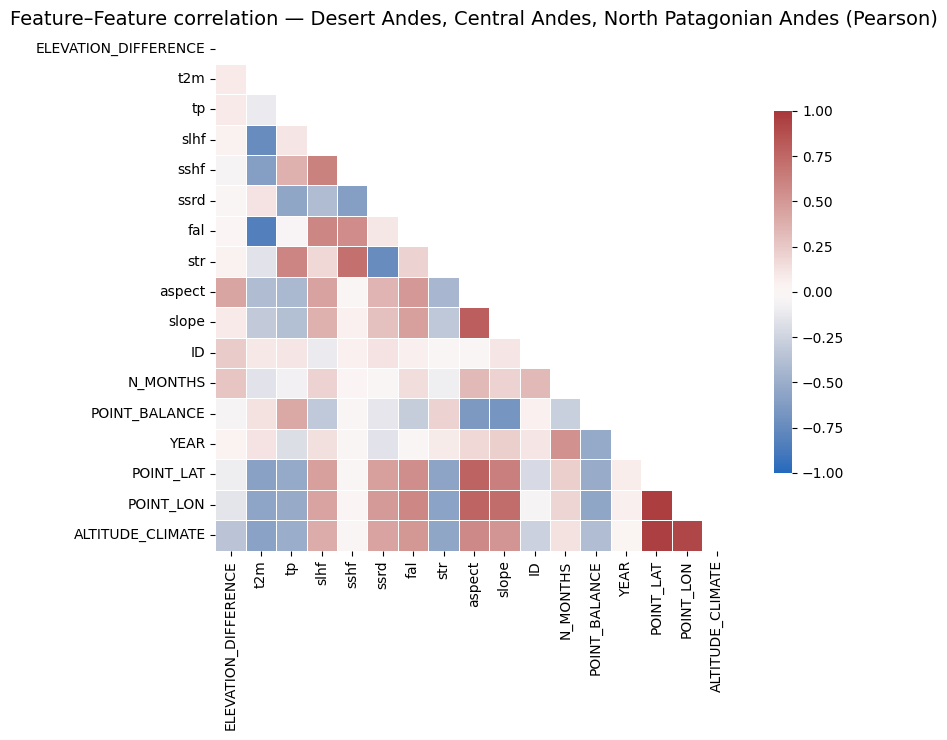

✓ Heatmap saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_features_spearman_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


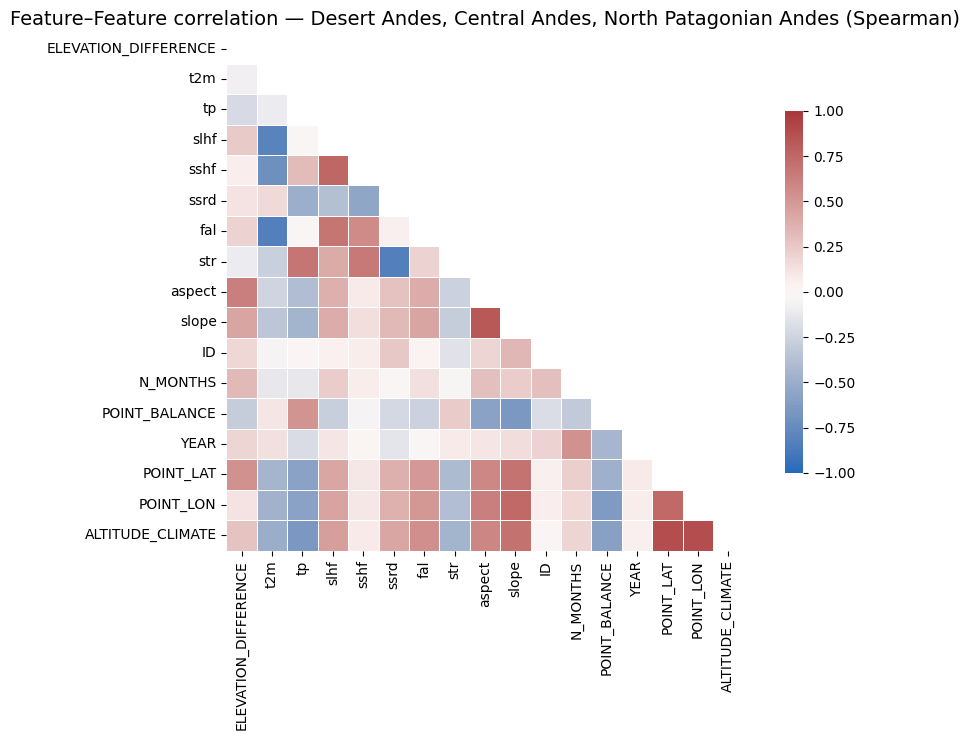

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_TARGET_pearson_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


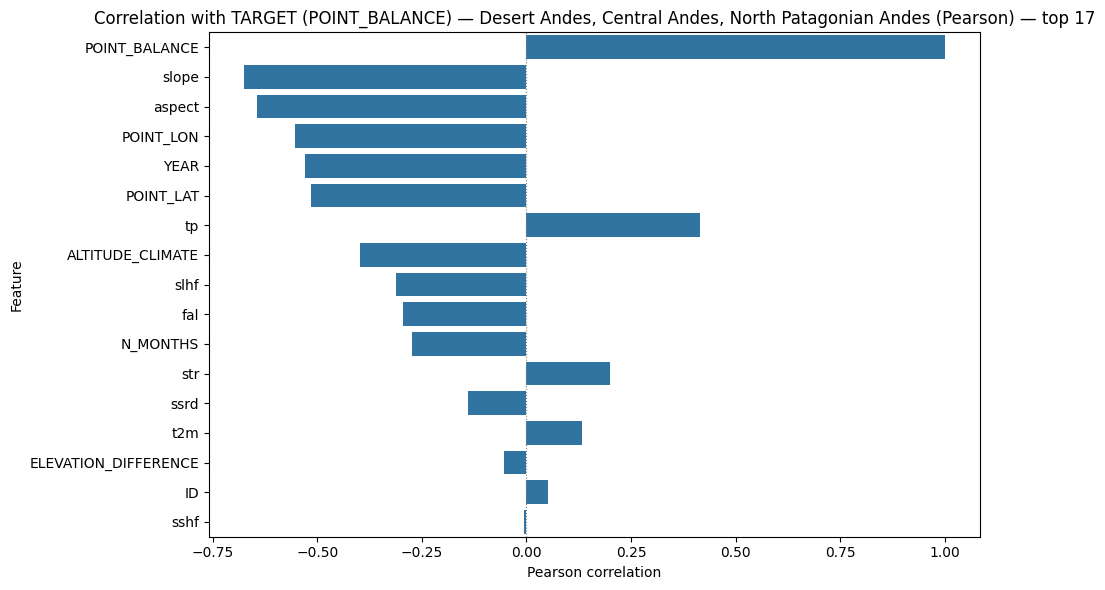

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_TARGET_spearman_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


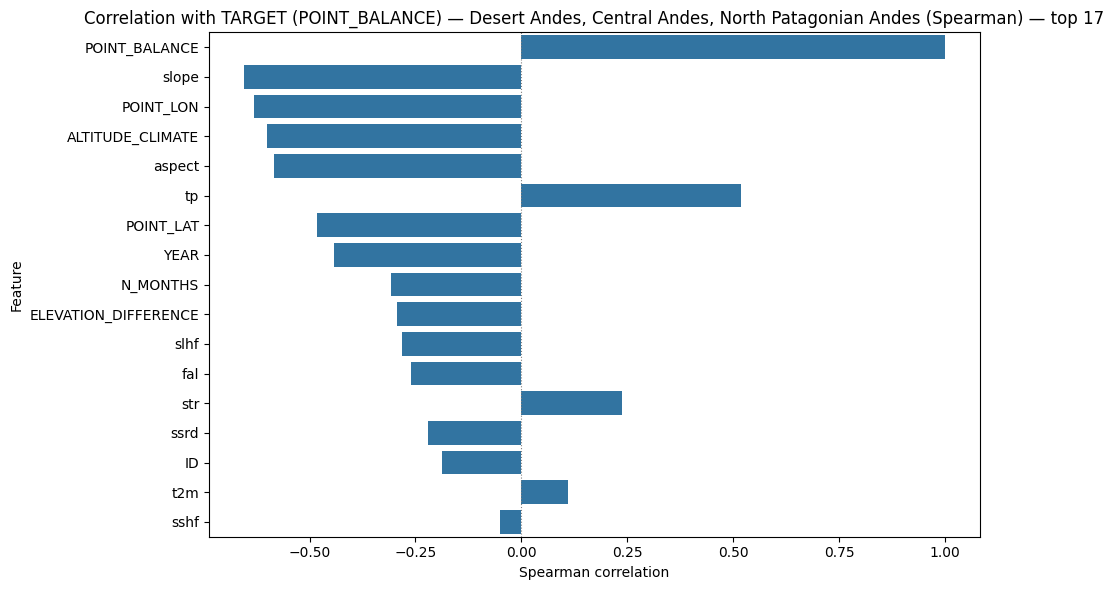

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_PRED_pearson_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


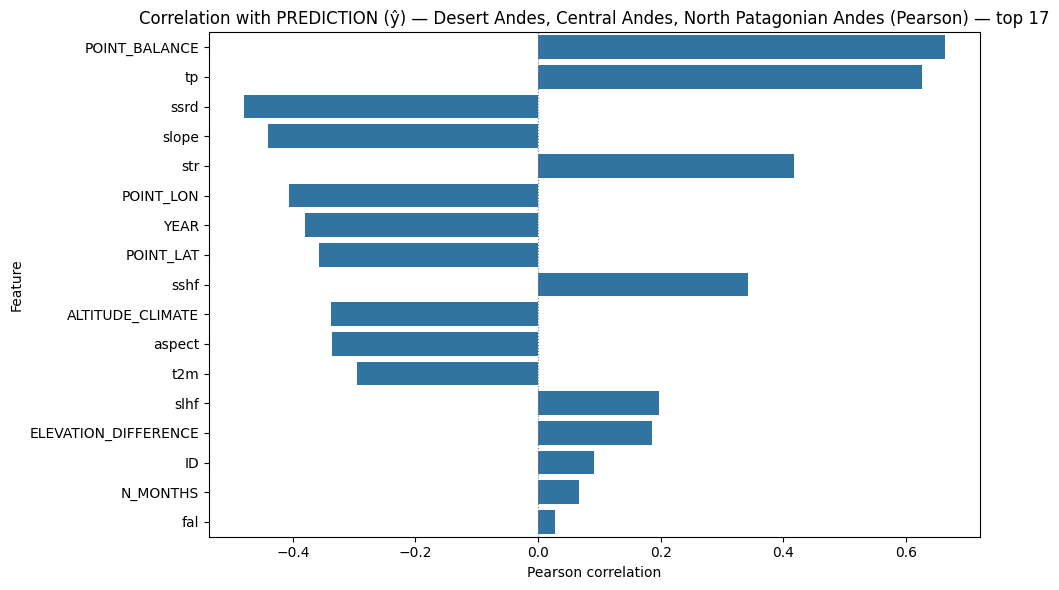

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_PRED_spearman_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250819_161318.png


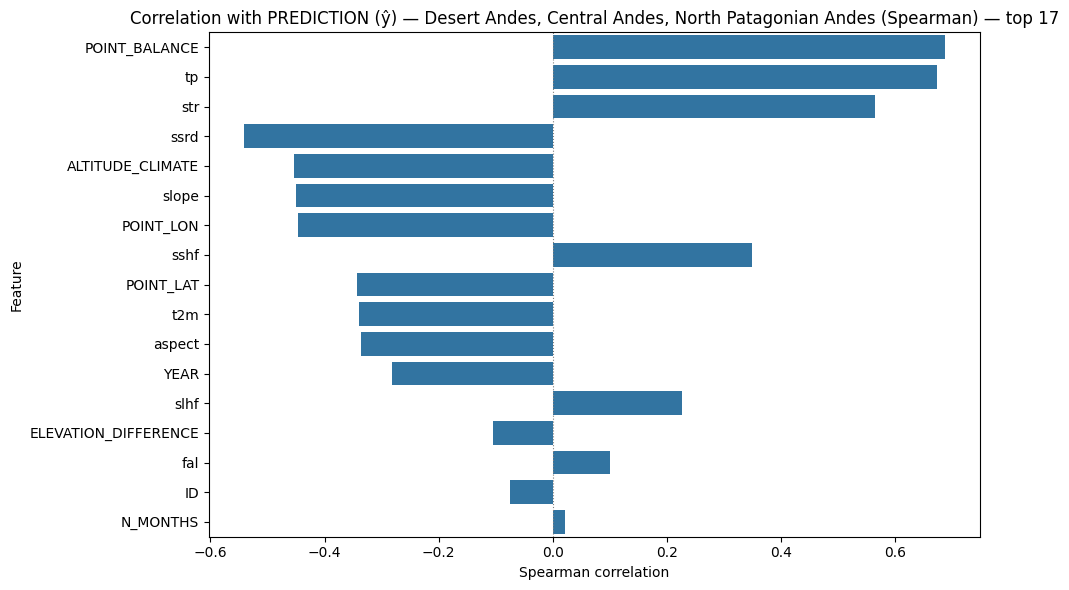

✓ Correlation analysis finished (descriptor-only X; target = POINT_BALANCE).


In [14]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import load

# ----------------------------
# Config & utils
# ----------------------------
def ensure_best_estimator(obj):
    return getattr(obj, 'best_estimator_', obj)

def make_test_from_regions(data, regions):
    if isinstance(regions, str):
        regions = [regions]
    wanted = {r.strip() for r in regions}
    df_sel = data[data['region'].astype(str).str.strip().isin(wanted)].copy()
    if df_sel.empty:
        raise ValueError(f"No rows found for selected regions: {sorted(wanted)}")
    X_sel = df_sel[all_columns]
    y_sel = df_sel['POINT_BALANCE'].values
    return df_sel, X_sel, y_sel

def plot_corr_heatmap(df_num, method='pearson', vmax=1.0, vmin=-1.0,
                      title='Feature correlation', savepath=None):
    corr = df_num.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    n = len(df_num.columns)
    fig_w = min(max(10, 0.4 * n), 24)
    fig_h = fig_w * 0.75

    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmin=vmin, vmax=vmax,
                square=True, linewidths=.5, cbar_kws={'shrink': .7})
    plt.title(f'{title} ({method.capitalize()})', fontsize=14)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f'✓ Heatmap saved: {savepath}')
    plt.show()
    return corr

def bar_corr_with_vector(df_num, vec, method='pearson', top_k=30,
                         title='Correlation with vector', savepath=None, xlabel=None):
    y_s = pd.Series(vec, index=df_num.index)
    vals = {}
    for col in df_num.columns:
        try:
            vals[col] = df_num[col].corr(y_s, method=method)
        except Exception:
            vals[col] = np.nan
    s = pd.Series(vals).dropna().sort_values(key=lambda v: v.abs(), ascending=False)
    if top_k is not None:
        s = s.head(top_k)

    plt.figure(figsize=(10, max(6, 0.35 * len(s))))
    sns.barplot(x=s.values, y=s.index, orient='h')
    plt.axvline(0, color='grey', linestyle=':', linewidth=0.8)
    plt.xlabel(xlabel or f'{method.capitalize()} correlation')
    plt.ylabel('Feature')
    plt.title(f'{title} ({method.capitalize()}) — top {len(s)}')
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f'✓ Barplot saved: {savepath}')
    plt.show()
    return s

# ----------------------------
# Paths, modelo y selección
# ----------------------------
obj = load('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_xgb_CA_NP.pkl')
xgb = ensure_best_estimator(obj)

out_dir  = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/CA_NP'
fig_path = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP'
os.makedirs(out_dir, exist_ok=True); os.makedirs(fig_path, exist_ok=True)

# Elige regiones para el análisis
analyze_regions = ["Desert Andes", "Central Andes", "North Patagonian Andes"]
df_sel, X_sel_w_target, y_sel = make_test_from_regions(data, analyze_regions)

# ============================
# Preparar DESCRIPTORES (X)
# ============================
# Quitar el target explícitamente de los descriptores
X_desc = X_sel_w_target.drop(columns=['POINT_BALANCE'], errors='ignore').copy()
X_desc = X_sel_w_target.drop(columns=['ID'], errors='ignore').copy()
X_desc = X_sel_w_target.drop(columns=['YEAR'], errors='ignore').copy()
X_desc = X_sel_w_target.drop(columns=['N_MONTH'], errors='ignore').copy()



# Mantener solo numéricas (bool->int)
bool_cols = X_desc.select_dtypes(include=['bool']).columns
if len(bool_cols):
    X_desc[bool_cols] = X_desc[bool_cols].astype(int)
num_cols = X_desc.select_dtypes(include=[np.number]).columns.tolist()
X_desc = X_desc[num_cols]

# Limpieza básica: quitar constantes / NaN excesivo, y rellenar faltantes
var = X_desc.var(numeric_only=True)
X_desc = X_desc[var[var > 0].index]
na_ratio = X_desc.isna().mean()
X_desc = X_desc[na_ratio[na_ratio < 0.2].index].fillna(method='ffill').fillna(method='bfill')

ts  = datetime.now().strftime('%Y%m%d_%H%M%S')
tag = "_".join(s.replace(" ", "") for s in analyze_regions)

# =====================================
# (1) Heatmaps de correlación (X vs X)
# =====================================
heatmap_p_path = os.path.join(fig_path, f'corr_features_pearson_{tag}_{ts}.png')
corr_ff_p = plot_corr_heatmap(
    X_desc, method='pearson',
    title=f'Feature–Feature correlation — {", ".join(analyze_regions)}',
    savepath=heatmap_p_path
)

heatmap_s_path = os.path.join(fig_path, f'corr_features_spearman_{tag}_{ts}.png')
corr_ff_s = plot_corr_heatmap(
    X_desc, method='spearman',
    title=f'Feature–Feature correlation — {", ".join(analyze_regions)}',
    savepath=heatmap_s_path
)

# =======================================================
# (2) Correlación de descriptores con el TARGET (y_sel)
# =======================================================
bar_y_p_path = os.path.join(fig_path, f'corr_with_TARGET_pearson_top_{tag}_{ts}.png')
corr_fx_y_p = bar_corr_with_vector(
    X_desc, y_sel, method='pearson', top_k=30,
    title=f'Correlation with TARGET (POINT_BALANCE) — {", ".join(analyze_regions)}',
    savepath=bar_y_p_path, xlabel='Pearson correlation'
)

bar_y_s_path = os.path.join(fig_path, f'corr_with_TARGET_spearman_top_{tag}_{ts}.png')
corr_fx_y_s = bar_corr_with_vector(
    X_desc, y_sel, method='spearman', top_k=30,
    title=f'Correlation with TARGET (POINT_BALANCE) — {", ".join(analyze_regions)}',
    savepath=bar_y_s_path, xlabel='Spearman correlation'
)

# ==============================================================
# (3) (Opcional) Correlación con la PREDICCIÓN del modelo (ŷ)
# ==============================================================

compute_corr_with_pred = True  # ponlo en False si no quieres esta parte
if compute_corr_with_pred:
    # Para crear features y predecir usa el df como en tu flujo (con POINT_BALANCE adentro si tu helper lo ignora)
    f_sel, m_sel = xgb._create_features_metadata(X_sel_w_target)
    y_pred = xgb.predict(f_sel)

    bar_yhat_p_path = os.path.join(fig_path, f'corr_with_PRED_pearson_top_{tag}_{ts}.png')
    corr_fx_yhat_p = bar_corr_with_vector(
        X_desc, y_pred, method='pearson', top_k=30,
        title=f'Correlation with PREDICTION (ŷ) — {", ".join(analyze_regions)}',
        savepath=bar_yhat_p_path, xlabel='Pearson correlation'
    )

    bar_yhat_s_path = os.path.join(fig_path, f'corr_with_PRED_spearman_top_{tag}_{ts}.png')
    corr_fx_yhat_s = bar_corr_with_vector(
        X_desc, y_pred, method='spearman', top_k=30,
        title=f'Correlation with PREDICTION (ŷ) — {", ".join(analyze_regions)}',
        savepath=bar_yhat_s_path, xlabel='Spearman correlation'
    )

# =============================
# Guardar matrices/series a CSV
# =============================
corr_ff_p.to_csv(os.path.join(out_dir, f'corr_matrix_features_pearson_{tag}_{ts}.csv'))
corr_ff_s.to_csv(os.path.join(out_dir, f'corr_matrix_features_spearman_{tag}_{ts}.csv'))

pd.DataFrame({'feature': corr_fx_y_p.index, 'pearson_with_TARGET': corr_fx_y_p.values}).to_csv(
    os.path.join(out_dir, f'corr_with_TARGET_pearson_top_{tag}_{ts}.csv'), index=False
)
pd.DataFrame({'feature': corr_fx_y_s.index, 'spearman_with_TARGET': corr_fx_y_s.values}).to_csv(
    os.path.join(out_dir, f'corr_with_TARGET_spearman_top_{tag}_{ts}.csv'), index=False
)

if compute_corr_with_pred:
    pd.DataFrame({'feature': corr_fx_yhat_p.index, 'pearson_with_PRED': corr_fx_yhat_p.values}).to_csv(
        os.path.join(out_dir, f'corr_with_PRED_pearson_top_{tag}_{ts}.csv'), index=False
    )
    pd.DataFrame({'feature': corr_fx_yhat_s.index, 'spearman_with_PRED': corr_fx_yhat_s.values}).to_csv(
        os.path.join(out_dir, f'corr_with_PRED_spearman_top_{tag}_{ts}.csv'), index=False
    )

print("✓ Correlation analysis finished (descriptor-only X; target = POINT_BALANCE).")


[BASELINE per fold]
    fold           R2         RMSE          MAE
0     1 0.8462551586 1.5391069134 1.1377202146
1     2 0.8162780377 1.5040473490 1.1270317126
2     3 0.8654450921 1.4207234463 1.0439781204
3     4 0.8305120247 1.6053920074 1.1807919527
4     5 0.8225062017 1.5599633059 1.1603433107
[BASELINE mean]
 fold   3.0000000000
R2     0.8361993030
RMSE   1.5258466044
MAE    1.1299730622
dtype: float64

[DROP-COLUMN] Head:
   feature      mean_ΔR2      std_ΔR2    mean_ΔRMSE    std_ΔRMSE     mean_ΔMAE  \
0      f0  0.0848073860 0.0223271844  0.3504733270 0.0647732157  0.2832366881   
4      f4  0.0069602166 0.0077088536  0.0333483377 0.0398102944  0.0254231320   
9      f9  0.0034397483 0.0028637757  0.0163742755 0.0134189248  0.0215786070   
1      f1  0.0027768418 0.0035981174  0.0121140309 0.0162273090  0.0095307074   
2      f2  0.0019079032 0.0033691149  0.0088293251 0.0164908664  0.0041721290   
7      f7  0.0015144400 0.0045824954  0.0059635630 0.0198780528  0.0059133037

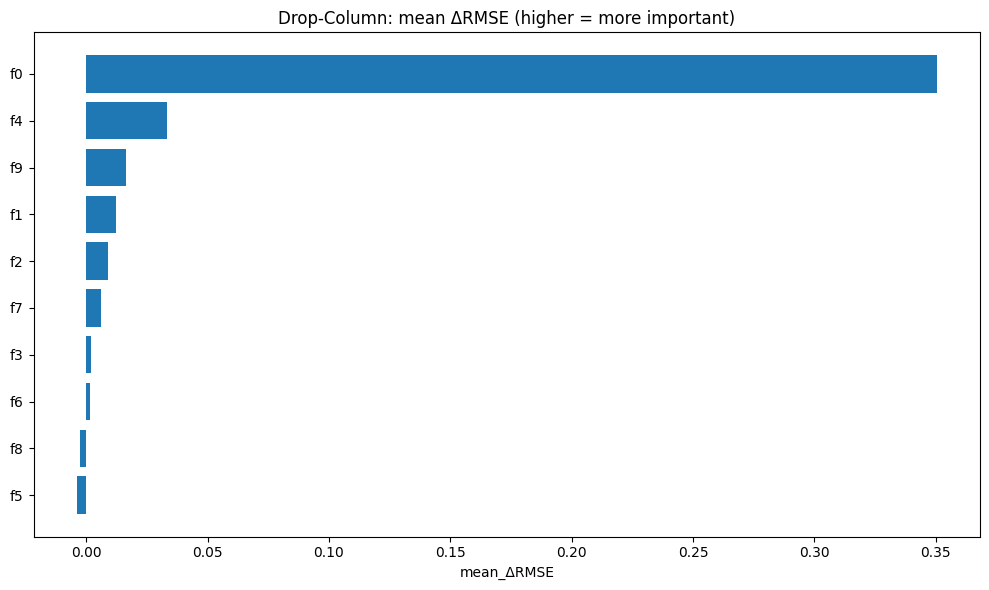

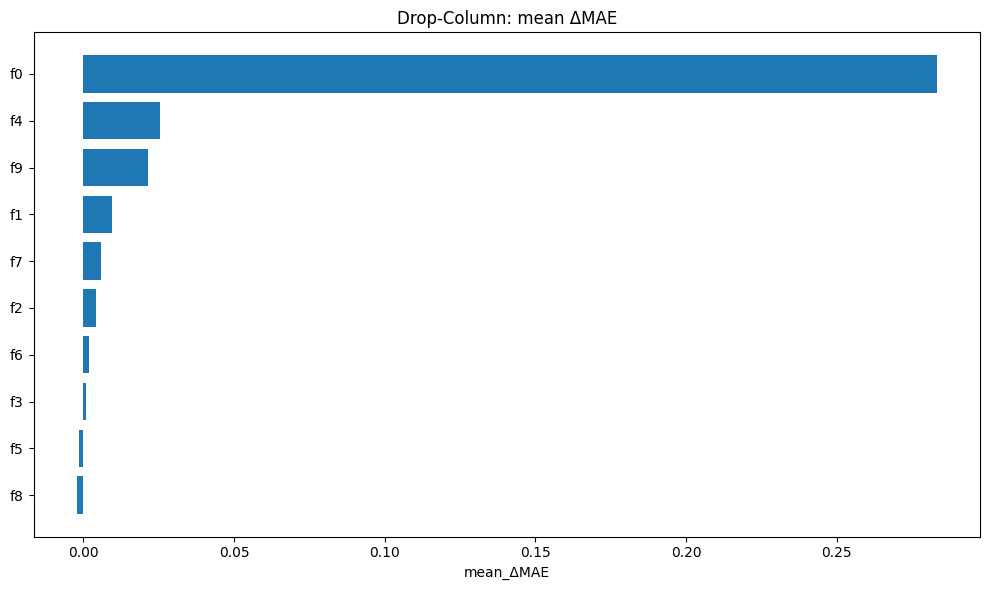

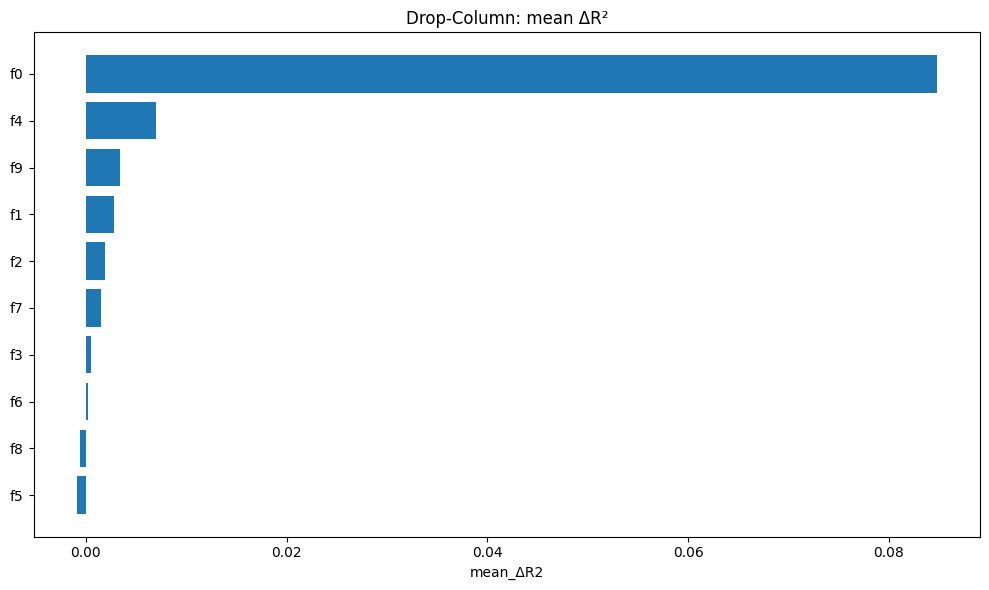

[ARTIFACTS] Saved under: /home/duilio/github/MassBalanceMachine/regions/Chile/dropcol_importance_results/run_20250819_175117
- dropcolumn_importance.csv
- bar_mean_dRMSE.png, bar_mean_dMAE.png, bar_mean_dR2.png


In [44]:
# ===============================================================
# Drop-Column Importance (CV) for Glacier Mass Balance (Regression)
# Importancia por Eliminación de Columna (CV) para Balance de Masa
# ===============================================================

import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.utils.validation import check_is_fitted

# You must have xgboost installed
# Debes tener xgboost instalado
import xgboost as xgb

# ------------------------------
# 0) Inputs assumed available
# 0) Entradas asumidas como disponibles
# ------------------------------
# - custom_xgboost: tu wrapper con _create_features_metadata
# - df_X_train: DataFrame CRUDO de entrenamiento (con metadata)
# - y_train: vector/Serie objetivo alineado con df_X_train
# - best_estimator: modelo ya ajustado (para clonar hiperparámetros)
#   Nota: NO lo usaremos para .fit, solo para extraer params

best_estimator = custom_xgboost.param_search.best_estimator_

# Optional grouping to avoid leakage across glaciers/years/etc.
# Agrupamiento opcional para evitar leakage entre glaciares/años/etc.
groups_series = None  # e.g., df_X_train['GLACIER_ID'] if available

# ------------------------------------------
# 1) Helper: build features (train/valid fold)
# 1) Helper: construir features (fold train/valid)
# ------------------------------------------
def build_features_from_raw(df_raw):
    # Use your helper to reproduce EXACT features as in training
    # Usa tu helper para reproducir EXACTAMENTE las features del entrenamiento
    X_feat_raw, _ = custom_xgboost._create_features_metadata(df_raw)
    # Ensure we have a DataFrame with column names
    # Asegurar DataFrame con nombres de columna
    if isinstance(X_feat_raw, pd.DataFrame):
        return X_feat_raw.copy()
    X_feat_raw = np.asarray(X_feat_raw)
    cols = [f"f{i}" for i in range(X_feat_raw.shape[1])]
    return pd.DataFrame(X_feat_raw, columns=cols)

# --------------------------------------------------
# 2) Helper: make an XGBRegressor "equivalent" clone
# 2) Helper: crear un XGBRegressor “equivalente”
# --------------------------------------------------
def make_equivalent_xgbregressor(best_estimator):
    # Try to extract xgboost parameters from the fitted wrapper
    # Intentar extraer parámetros xgboost del wrapper entrenado
    params = {}
    # Common attributes in sklearn API
    try:
        params.update(best_estimator.get_xgb_params())
    except Exception:
        try:
            params.update(best_estimator.get_params(deep=False))
        except Exception:
            params = {}
    # Keep only params supported by XGBRegressor
    # Conservar solo params soportados por XGBRegressor
    valid_keys = set(xgb.XGBRegressor().get_params().keys())
    clean = {k: v for k, v in params.items() if k in valid_keys}

    # Make sure important keys propagate (tree_method, n_estimators, etc.)
    # Asegurar que llaves importantes se propaguen (tree_method, n_estimators, etc.)
    booster = best_estimator.get_booster()
    try:
        n_estimators = best_estimator.get_params().get("n_estimators", None)
    except Exception:
        n_estimators = None
    if n_estimators is None:
        # Fallback: trees in booster
        # Respaldo: número de árboles en el booster
        try:
            n_estimators = len(booster.get_dump())
        except Exception:
            n_estimators = 500  # sensible default / default razonable

    clean.setdefault("n_estimators", n_estimators)
    # Ensure objective is regression
    # Asegurar objetivo de regresión
    clean.setdefault("objective", "reg:squarederror")
    # Avoid verbosity spam
    # Evitar verbosidad
    clean.setdefault("verbosity", 0)
    # Device / tree method if present
    # Dispositivo / método de árbol si existe
    if "device" in best_estimator.get_params():
        clean["device"] = best_estimator.get_params()["device"]

    # Build regressor
    # Construir regresor
    reg = xgb.XGBRegressor(**clean)
    return reg

# ------------------------------------------------
# 3) CV splitter and metric helpers
# 3) Particionador de CV y helpers de métricas
# ------------------------------------------------
def rmse(y_true, y_pred):  # physical units of mass balance
    # Unidades físicas del balance de masa
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

n_splits = 5
if groups_series is None:
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    split_iter = splitter.split(df_X_train, y_train)
else:
    assert len(groups_series) == len(df_X_train), "groups_series must align with df_X_train"
    splitter = GroupKFold(n_splits=n_splits)
    split_iter = splitter.split(df_X_train, y_train, groups=groups_series)

fold_indices = list(split_iter)

# --------------------------------------------
# 4) Baseline per fold (all features present)
# 4) Baseline por fold (todas las features)
# --------------------------------------------
baseline_scores = []
for k, (tr_idx, va_idx) in enumerate(fold_indices, 1):
    df_tr_raw = df_X_train.iloc[tr_idx]
    df_va_raw = df_X_train.iloc[va_idx]
    ytr = pd.Series(y_train).iloc[tr_idx].values
    yva = pd.Series(y_train).iloc[va_idx].values

    Xtr = build_features_from_raw(df_tr_raw)
    Xva = build_features_from_raw(df_va_raw)

    reg = make_equivalent_xgbregressor(best_estimator)
    # Early stopping if supported
    # Early stopping si se soporta
    try:
        reg.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    except TypeError:
        reg.fit(Xtr, ytr)

    yhat = reg.predict(Xva)
    baseline_scores.append({
        "fold": k,
        "R2":  float(r2_score(yva, yhat)),
        "RMSE": rmse(yva, yhat),
        "MAE":  mae(yva, yhat),
    })

baseline_df = pd.DataFrame(baseline_scores)
print("[BASELINE per fold]\n", baseline_df)
print("[BASELINE mean]\n", baseline_df.mean(numeric_only=True))

# --------------------------------------------
# 5) Drop-Column loop: remove each feature
# 5) Bucle Drop-Column: eliminar cada feature
# --------------------------------------------
# Use the feature space inferred from any fold's Xtr
# Usar el espacio de features inferido del Xtr de cualquier fold
# (Construimos una vez desde todo el df_X_train para nombres estables)
X_all_features = build_features_from_raw(df_X_train)
all_features = list(X_all_features.columns)

results = []
for feat in all_features:
    fold_rows = []
    for k, (tr_idx, va_idx) in enumerate(fold_indices, 1):
        df_tr_raw = df_X_train.iloc[tr_idx]
        df_va_raw = df_X_train.iloc[va_idx]
        ytr = pd.Series(y_train).iloc[tr_idx].values
        yva = pd.Series(y_train).iloc[va_idx].values

        # Build full feature matrices for this fold
        # Construir matrices de features completas para este fold
        Xtr_full = build_features_from_raw(df_tr_raw)
        Xva_full = build_features_from_raw(df_va_raw)

        if feat not in Xtr_full.columns:
            # If feature not present in this fold (shouldn't happen), skip gracefully
            # Si la feature no está en este fold (no debería), saltar
            continue

        # Drop the feature for this fold
        # Eliminar la feature para este fold
        Xtr_drop = Xtr_full.drop(columns=[feat])
        Xva_drop = Xva_full.drop(columns=[feat])

        reg = make_equivalent_xgbregressor(best_estimator)
        try:
            reg.fit(Xtr_drop, ytr, eval_set=[(Xva_drop, yva)], verbose=False)
        except TypeError:
            reg.fit(Xtr_drop, ytr)

        yhat_drop = reg.predict(Xva_drop)

        # Baseline metrics for this fold
        # Métricas baseline para este fold
        base = baseline_df[baseline_df["fold"] == k].iloc[0]
        # Deltas: positive Δ => worse when dropped => important
        # Deltas: Δ positiva => peor al quitar => importante
        fold_rows.append({
            "fold": k,
            "feature": feat,
            "ΔR2":   base["R2"]  - float(r2_score(yva, yhat_drop)),
            "ΔRMSE": float(rmse(yva, yhat_drop)) - base["RMSE"],
            "ΔMAE":  float(mae(yva, yhat_drop))  - base["MAE"],
        })

    if not fold_rows:
        continue
    fdf = pd.DataFrame(fold_rows)
    results.append({
        "feature": feat,
        "mean_ΔR2":   fdf["ΔR2"].mean(),
        "std_ΔR2":    fdf["ΔR2"].std(ddof=1),
        "mean_ΔRMSE": fdf["ΔRMSE"].mean(),
        "std_ΔRMSE":  fdf["ΔRMSE"].std(ddof=1),
        "mean_ΔMAE":  fdf["ΔMAE"].mean(),
        "std_ΔMAE":   fdf["ΔMAE"].std(ddof=1),
    })

dc_df = pd.DataFrame(results).sort_values("mean_ΔRMSE", ascending=False)
print("\n[DROP-COLUMN] Head:\n", dc_df.head(10))

# --------------------------------------------
# 6) Save & plot
# 6) Guardar y graficar
# --------------------------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
outdir = Path(os.getcwd()) / "dropcol_importance_results" / f"run_{ts}"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "dropcolumn_importance.csv"
dc_df.to_csv(csv_path, index=False)
print(f"[INFO] Saved CSV -> {csv_path}")

def plot_bar(df, col, title, fname, topk=None):
    d = df.copy()
    if topk:
        d = d.head(topk)
    plt.figure(figsize=(10, 6))
    plt.barh(d["feature"][::-1], d[col][::-1])
    plt.xlabel(col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outdir / fname, dpi=300)
    plt.show()

topk = min(15, len(dc_df))
plot_bar(dc_df, "mean_ΔRMSE", "Drop-Column: mean ΔRMSE (higher = more important)", "bar_mean_dRMSE.png", topk=topk)
plot_bar(dc_df.sort_values("mean_ΔMAE", ascending=False), "mean_ΔMAE", "Drop-Column: mean ΔMAE", "bar_mean_dMAE.png", topk=topk)
plot_bar(dc_df.sort_values("mean_ΔR2", ascending=False), "mean_ΔR2", "Drop-Column: mean ΔR²", "bar_mean_dR2.png", topk=topk)

print(f"[ARTIFACTS] Saved under: {outdir}")
print("- dropcolumn_importance.csv")
print("- bar_mean_dRMSE.png, bar_mean_dMAE.png, bar_mean_dR2.png")

